In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Others/cardekho.csv")

In [67]:
print("Rows, cols:", df.shape)

Rows, cols: (8128, 12)


In [68]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [69]:
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

In [70]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             216
seats                 221
dtype: int64


In [71]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate Rows:")
    display(df[df.duplicated()])

Number of duplicate rows: 1202

Duplicate Rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
291,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.90,1197.0,82.00,5.0
296,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.60,1197.0,85.80,5.0
370,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.60,1999.0,177.00,5.0
371,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37,2487.0,214.56,5.0
372,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33,1999.0,177.00,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7987,Renault Captur 1.5 Diesel RXT,2018,1265000,12000,Diesel,Individual,Manual,First Owner,20.37,1461.0,108.45,5.0
7988,Maruti Ciaz Alpha Diesel,2019,1025000,32000,Diesel,Individual,Manual,First Owner,28.09,1248.0,88.50,5.0
8117,Maruti Swift Dzire VDI,2015,625000,50000,Diesel,Individual,Manual,First Owner,26.59,1248.0,74.00,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70.00,5.0


In [72]:
df = df.drop_duplicates().reset_index(drop=True)

In [73]:
df.shape

(6926, 12)

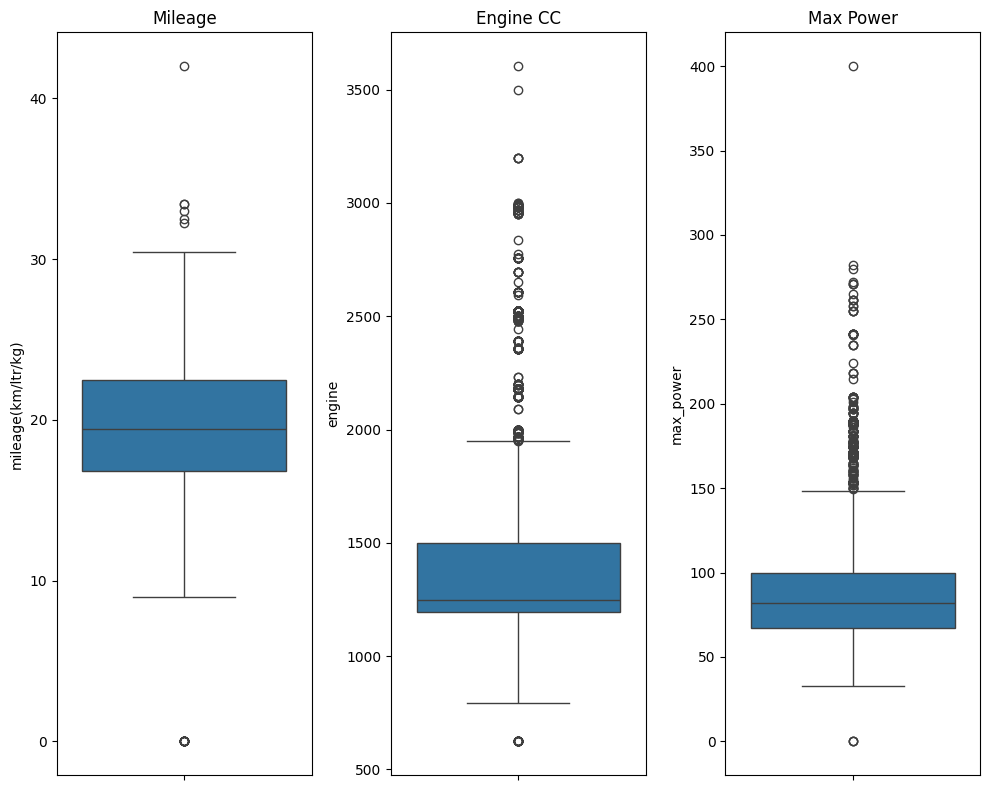

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.subplot(1, 3, 1)
sns.boxplot(data=df, y='mileage(km/ltr/kg)')
plt.title('Mileage')

plt.subplot(1, 3, 2)
sns.boxplot(data=df, y='engine')
plt.title('Engine CC')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, y='max_power')
plt.title('Max Power')



plt.tight_layout()
plt.show()

In [75]:
# Now impute missing values using median
df['mileage(km/ltr/kg)'] = df['mileage(km/ltr/kg)'].fillna(df['mileage(km/ltr/kg)'].median())
df['engine'] = df['engine'].fillna(df['engine'].median())
df['max_power'] = df['max_power'].fillna(df['max_power'].median())

# For 'seats' (categorical), convert to int/float first if needed, then mode
df['seats'] = pd.to_numeric(df['seats'], errors='coerce')  # optional: if it's stored as string
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])  # mode imputation

In [76]:
df.shape

(6926, 12)

In [77]:
print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64


## **A. Split name into brand and model**

In [78]:
df['brand'] = df['name'].str.split().str[0]
df['model'] = df['name'].str.split(n=1).str[1]
df.drop(columns=['name'], inplace=True)

## **B. Create Binary Flags for Model Keywords**


In [79]:
keywords = ['VXI', 'VDI', 'EXi', 'Ambition', 'Sportz', 'BSIII', 'Di', 'Turbo', 'GT', 'SX', 'LXI', 'ZXI']
for kw in keywords:
    df[f'model_has_{kw}'] = df['model'].str.contains(kw, case=False, na=False).astype(int)

## **C. Add Text-Based Features from model**

In [80]:
df['model_name_length'] = df['model'].str.len()
df['model_word_count'] = df['model'].str.split().str.len()

## **D. Calculate Car Age**

In [81]:
current_year = 2025
df['age'] = current_year - df['year']

## **E. Price Per Kilometer Driven**

In [82]:
df['price_per_km'] = df['selling_price'] / df['km_driven'].replace(0, np.nan)

=== BASIC STATISTICS FOR mileage(km/ltr/kg) ===
count    6926.000000
mean       19.464550
std         3.987878
min         0.000000
25%        16.950000
50%        19.440000
75%        22.320000
max        42.000000
Name: mileage(km/ltr/kg), dtype: float64


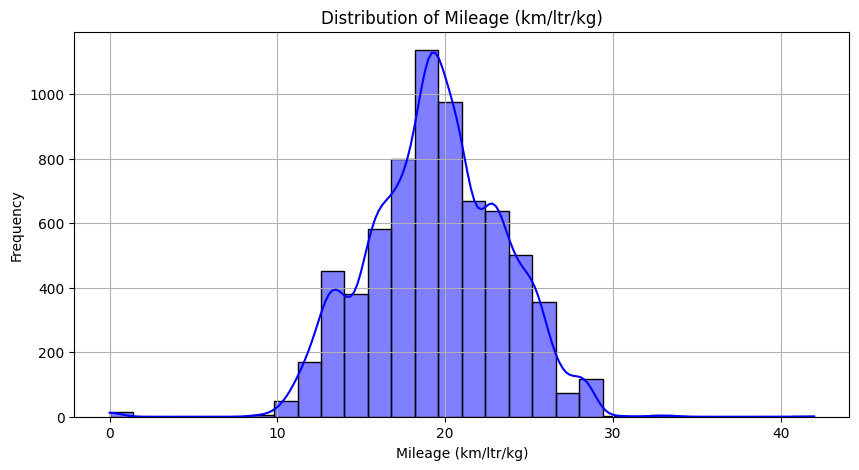

In [83]:
print("=== BASIC STATISTICS FOR mileage(km/ltr/kg) ===")
print(df['mileage(km/ltr/kg)'].describe())


plt.figure(figsize=(10, 5))

sns.histplot(df['mileage(km/ltr/kg)'], kde=True, bins=30, color='blue')
plt.title('Distribution of Mileage (km/ltr/kg)')
plt.xlabel('Mileage (km/ltr/kg)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## **F. Categorize Mileage into Bins**

In [84]:
df['mileage(km/ltr/kg)'] = df['mileage(km/ltr/kg)'].clip(upper=40)
df['mileage_category'] = pd.cut(df['mileage(km/ltr/kg)'], bins=[0,10,15,20,25,30,40],
                                labels=['Very Low','Low','Medium','High','Very High','Ultra High'],
                                include_lowest=True)


## **G. Engine to Power Ratio**

In [85]:
df['max_power'] = df['max_power'].replace(0, np.nan).fillna(df['max_power'].median())
df['engine_power_ratio'] = df['engine'] / df['max_power']


In [86]:
print("Missing values per column after creating new features:\n", df.isnull().sum())
print("\nData types after creating new features:\n", df.dtypes)
print("\nFirst 5 rows of the final DataFrame:")
print(df.head().to_string())

Missing values per column after creating new features:
 year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
brand                 0
model                 0
model_has_VXI         0
model_has_VDI         0
model_has_EXi         0
model_has_Ambition    0
model_has_Sportz      0
model_has_BSIII       0
model_has_Di          0
model_has_Turbo       0
model_has_GT          0
model_has_SX          0
model_has_LXI         0
model_has_ZXI         0
model_name_length     0
model_word_count      0
age                   0
price_per_km          0
mileage_category      0
engine_power_ratio    0
dtype: int64

Data types after creating new features:
 year                     int64
selling_price            int64
km_driven                int64
fuel                    object
seller_type          

## **Cap Outliers in All Numeric Columns**

In [87]:
numeric_cols = [
    'selling_price', 'km_driven', 'mileage(km/ltr/kg)',
    'engine', 'max_power', 'seats', 'age',
    'price_per_km', 'engine_power_ratio'
]

In [88]:
def plot_before_after_boxplot(df, col, figsize=(10, 5)):
    # Create a copy to avoid modifying original
    df_temp = df.copy()

    # Calculate IQR bounds for capping
    Q1 = df_temp[col].quantile(0.25)
    Q3 = df_temp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Plot before
    plt.figure(figsize=figsize)
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df_temp, y=col)
    plt.title(f'{col} (Before Capping)\nIQR: [{lower_bound:.2f}, {upper_bound:.2f}]')
    plt.ylabel(col)

    # Cap outliers
    df_temp[col] = df_temp[col].clip(lower=lower_bound, upper=upper_bound)

    # Plot after
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_temp, y=col)
    plt.title(f'{col} (After Capping)')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

    return df_temp


 SELLING_PRICE


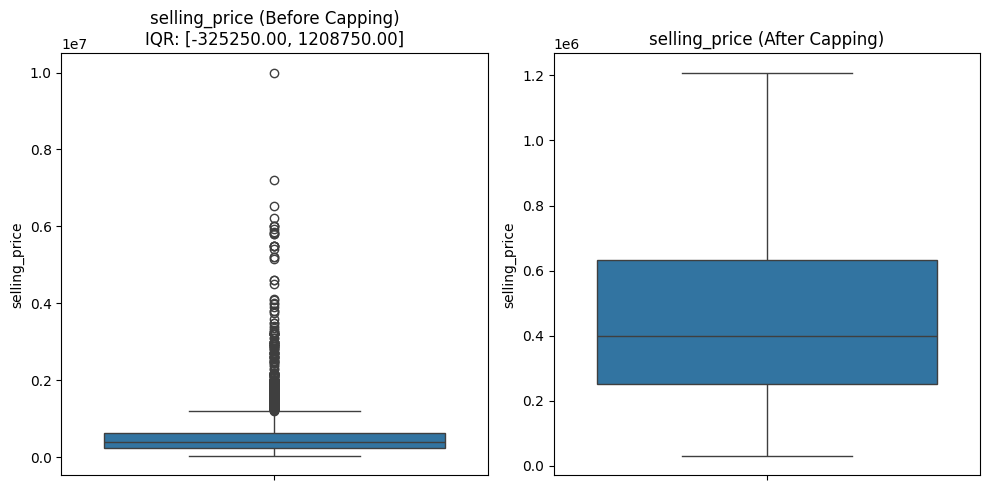


 KM_DRIVEN


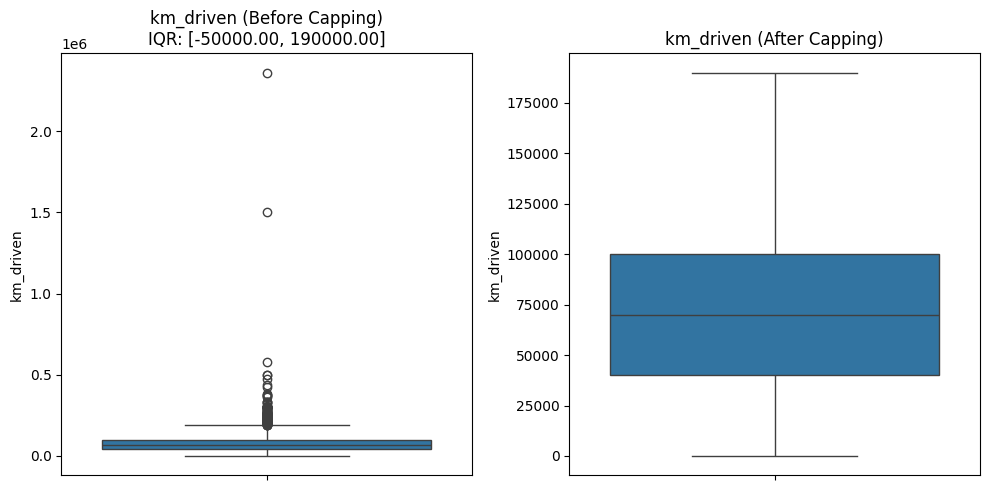


 MILEAGE(KM/LTR/KG)


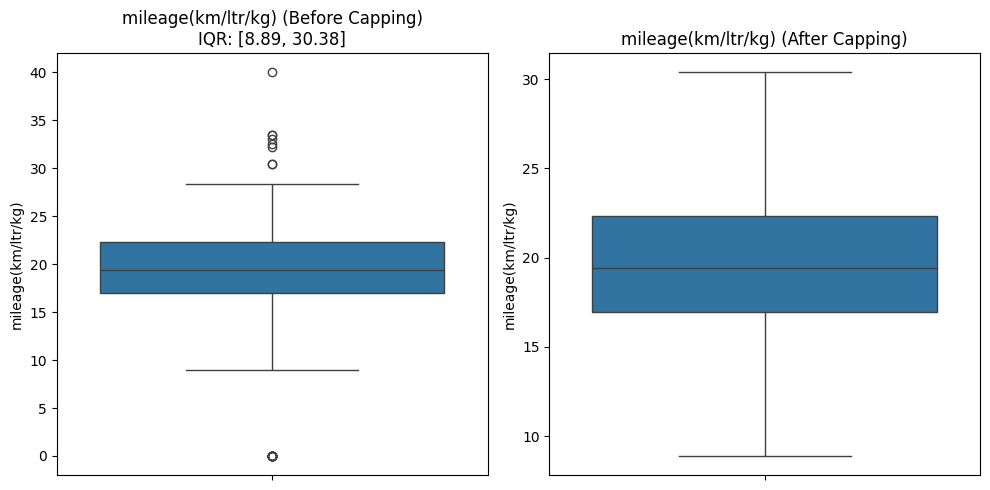


 ENGINE


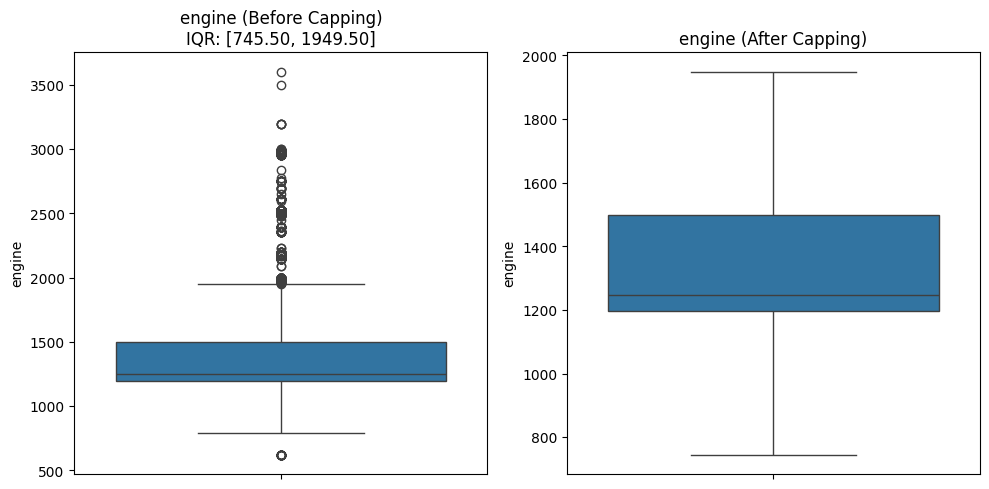


 MAX_POWER


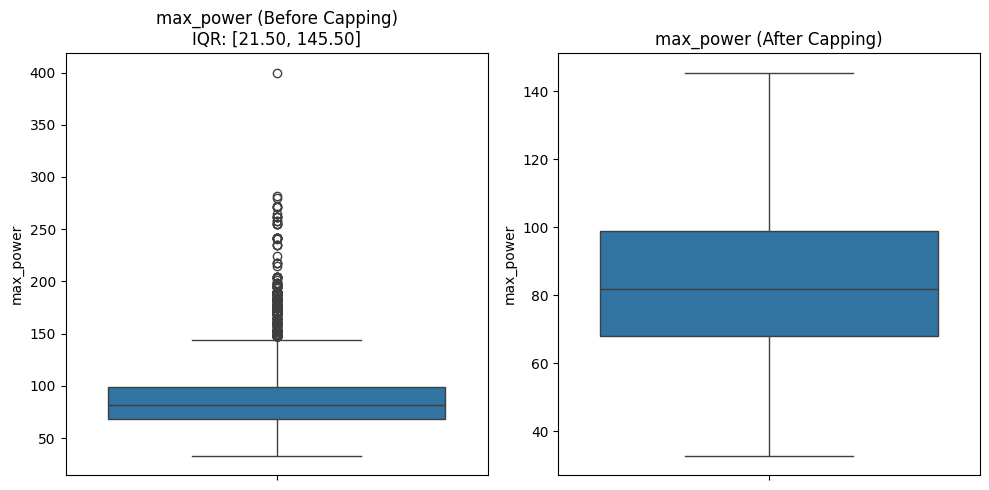


 SEATS


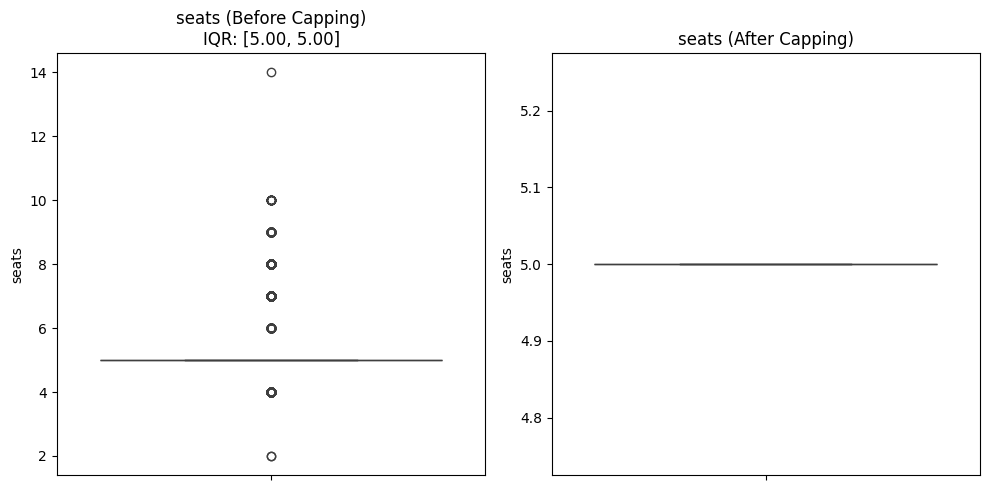


 AGE


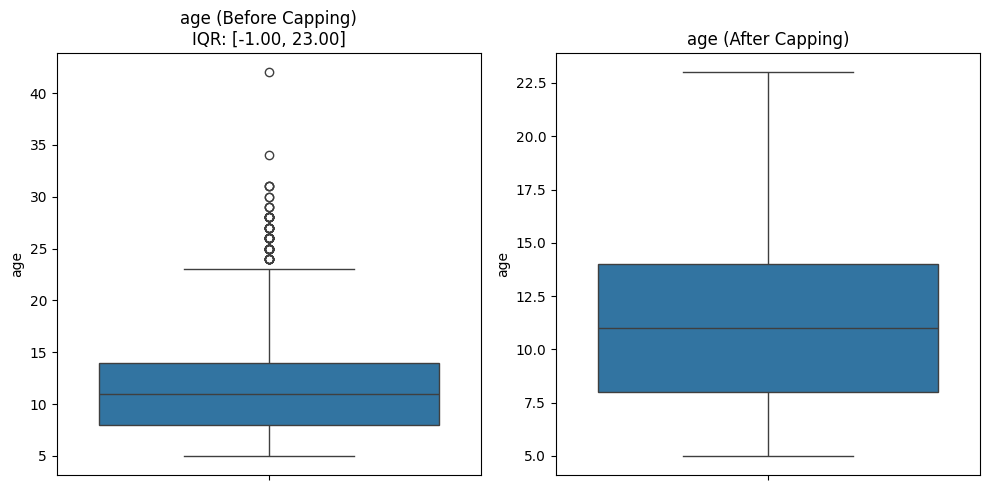


 PRICE_PER_KM


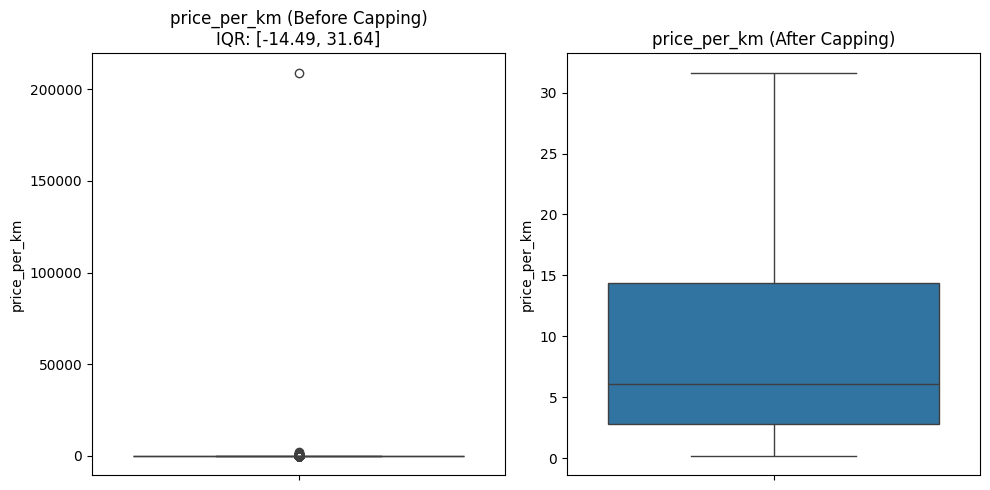


 ENGINE_POWER_RATIO


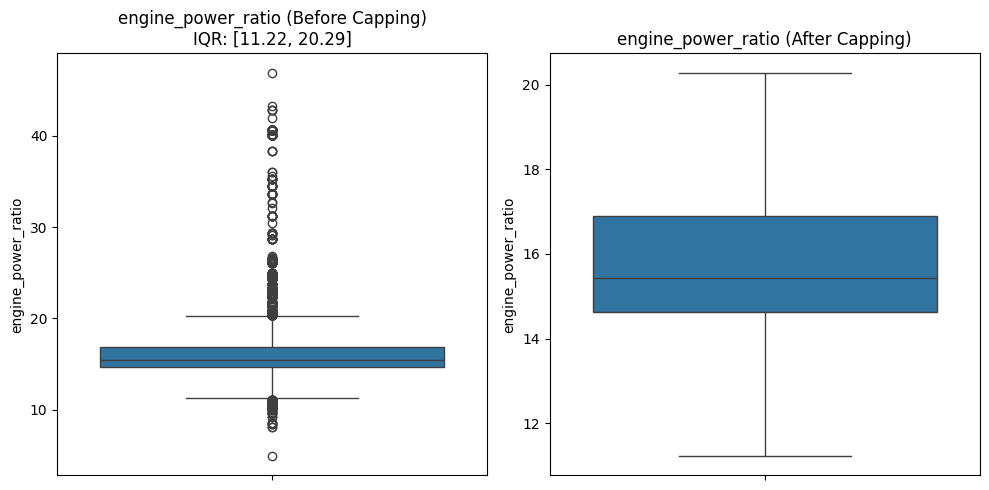

In [89]:
for col in numeric_cols:
    print(f"\n {col.upper()}")
    df = plot_before_after_boxplot(df, col)

In [90]:
categorical_cols = [
    'fuel', 'seller_type', 'transmission', 'owner',
    'brand', 'model', 'mileage_category'
]

In [91]:
def plot_top_categories(df, col, top_n=10, figsize=(10, 6)):
    # Get value counts
    value_counts = df[col].value_counts().head(top_n)

    plt.figure(figsize=figsize)
    sns.barplot(x=value_counts.values, y=value_counts.index, palette='viridis')
    plt.title(f'Top {top_n} Categories in "{col}"')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    print(f" Unique categories in '{col}': {df[col].nunique()}")
    print(f"Top {top_n} values:\n{value_counts}\n")


 FUEL


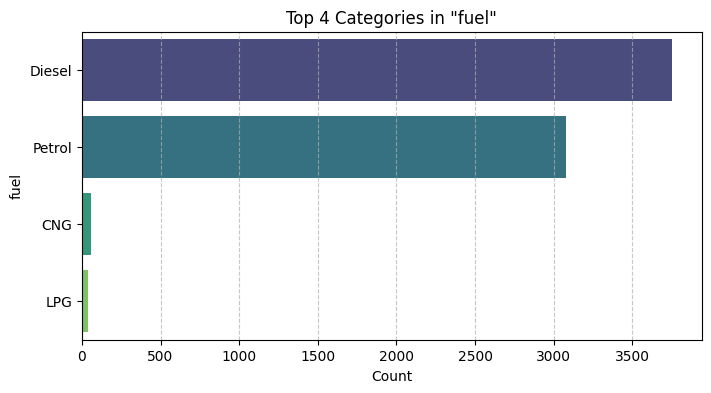

 Unique categories in 'fuel': 4
Top 4 values:
fuel
Diesel    3755
Petrol    3077
CNG         56
LPG         38
Name: count, dtype: int64


 SELLER_TYPE


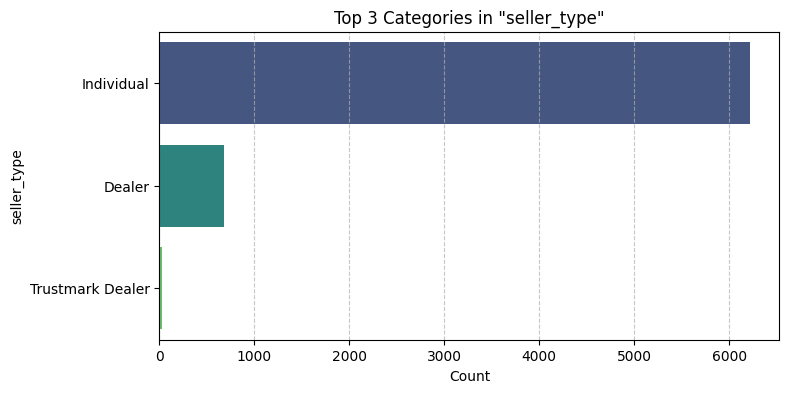

 Unique categories in 'seller_type': 3
Top 3 values:
seller_type
Individual          6218
Dealer               681
Trustmark Dealer      27
Name: count, dtype: int64


 TRANSMISSION


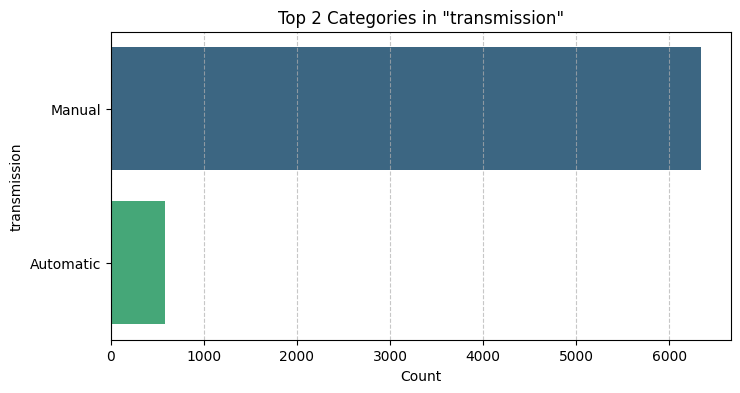

 Unique categories in 'transmission': 2
Top 2 values:
transmission
Manual       6342
Automatic     584
Name: count, dtype: int64


 OWNER


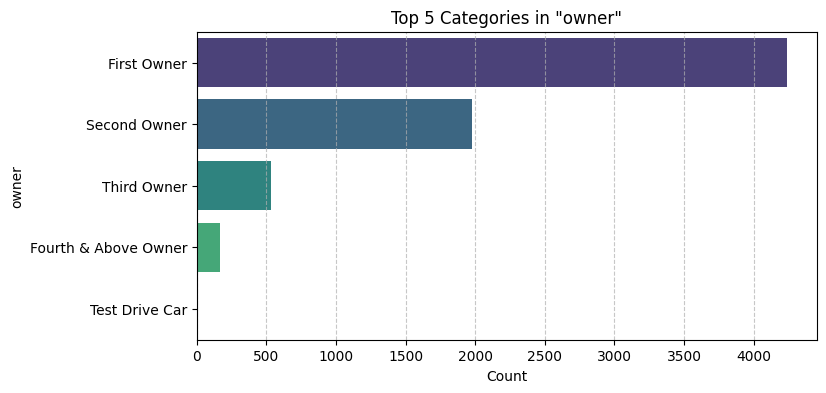

 Unique categories in 'owner': 5
Top 5 values:
owner
First Owner             4242
Second Owner            1974
Third Owner              536
Fourth & Above Owner     169
Test Drive Car             5
Name: count, dtype: int64


 MILEAGE_CATEGORY


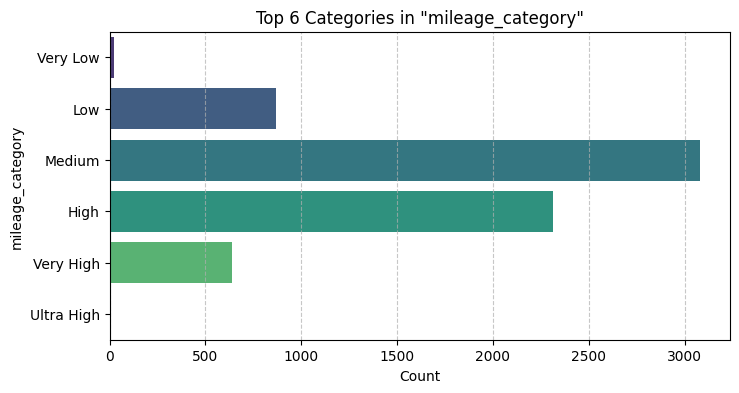

 Unique categories in 'mileage_category': 6
Top 6 values:
mileage_category
Medium        3080
High          2312
Low            867
Very High      637
Very Low        22
Ultra High       8
Name: count, dtype: int64



In [92]:
regular_cats = ['fuel', 'seller_type', 'transmission', 'owner', 'mileage_category']

for col in regular_cats:
    print(f"\n {col.upper()}")
    plot_top_categories(df, col, top_n=df[col].nunique(), figsize=(8, 4))


 BRAND (Top 20)


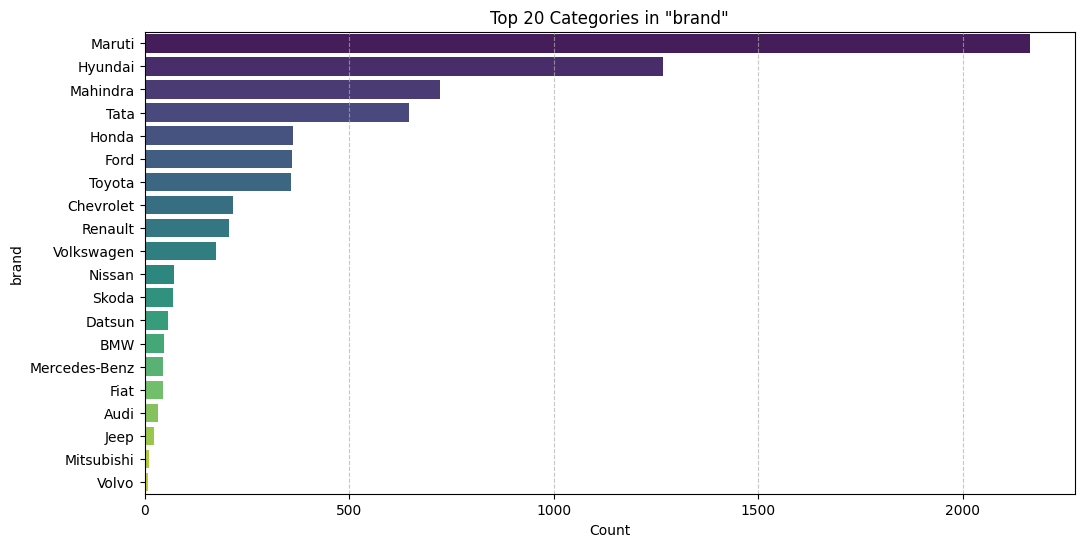

 Unique categories in 'brand': 32
Top 20 values:
brand
Maruti           2165
Hyundai          1267
Mahindra          723
Tata              647
Honda             362
Ford              361
Toyota            357
Chevrolet         216
Renault           206
Volkswagen        174
Nissan             73
Skoda              70
Datsun             57
BMW                47
Mercedes-Benz      46
Fiat               44
Audi               33
Jeep               22
Mitsubishi         11
Volvo               9
Name: count, dtype: int64



In [93]:
print("\n BRAND (Top 20)")
plot_top_categories(df, 'brand', top_n=20, figsize=(12, 6))


 MODEL (Top 30)


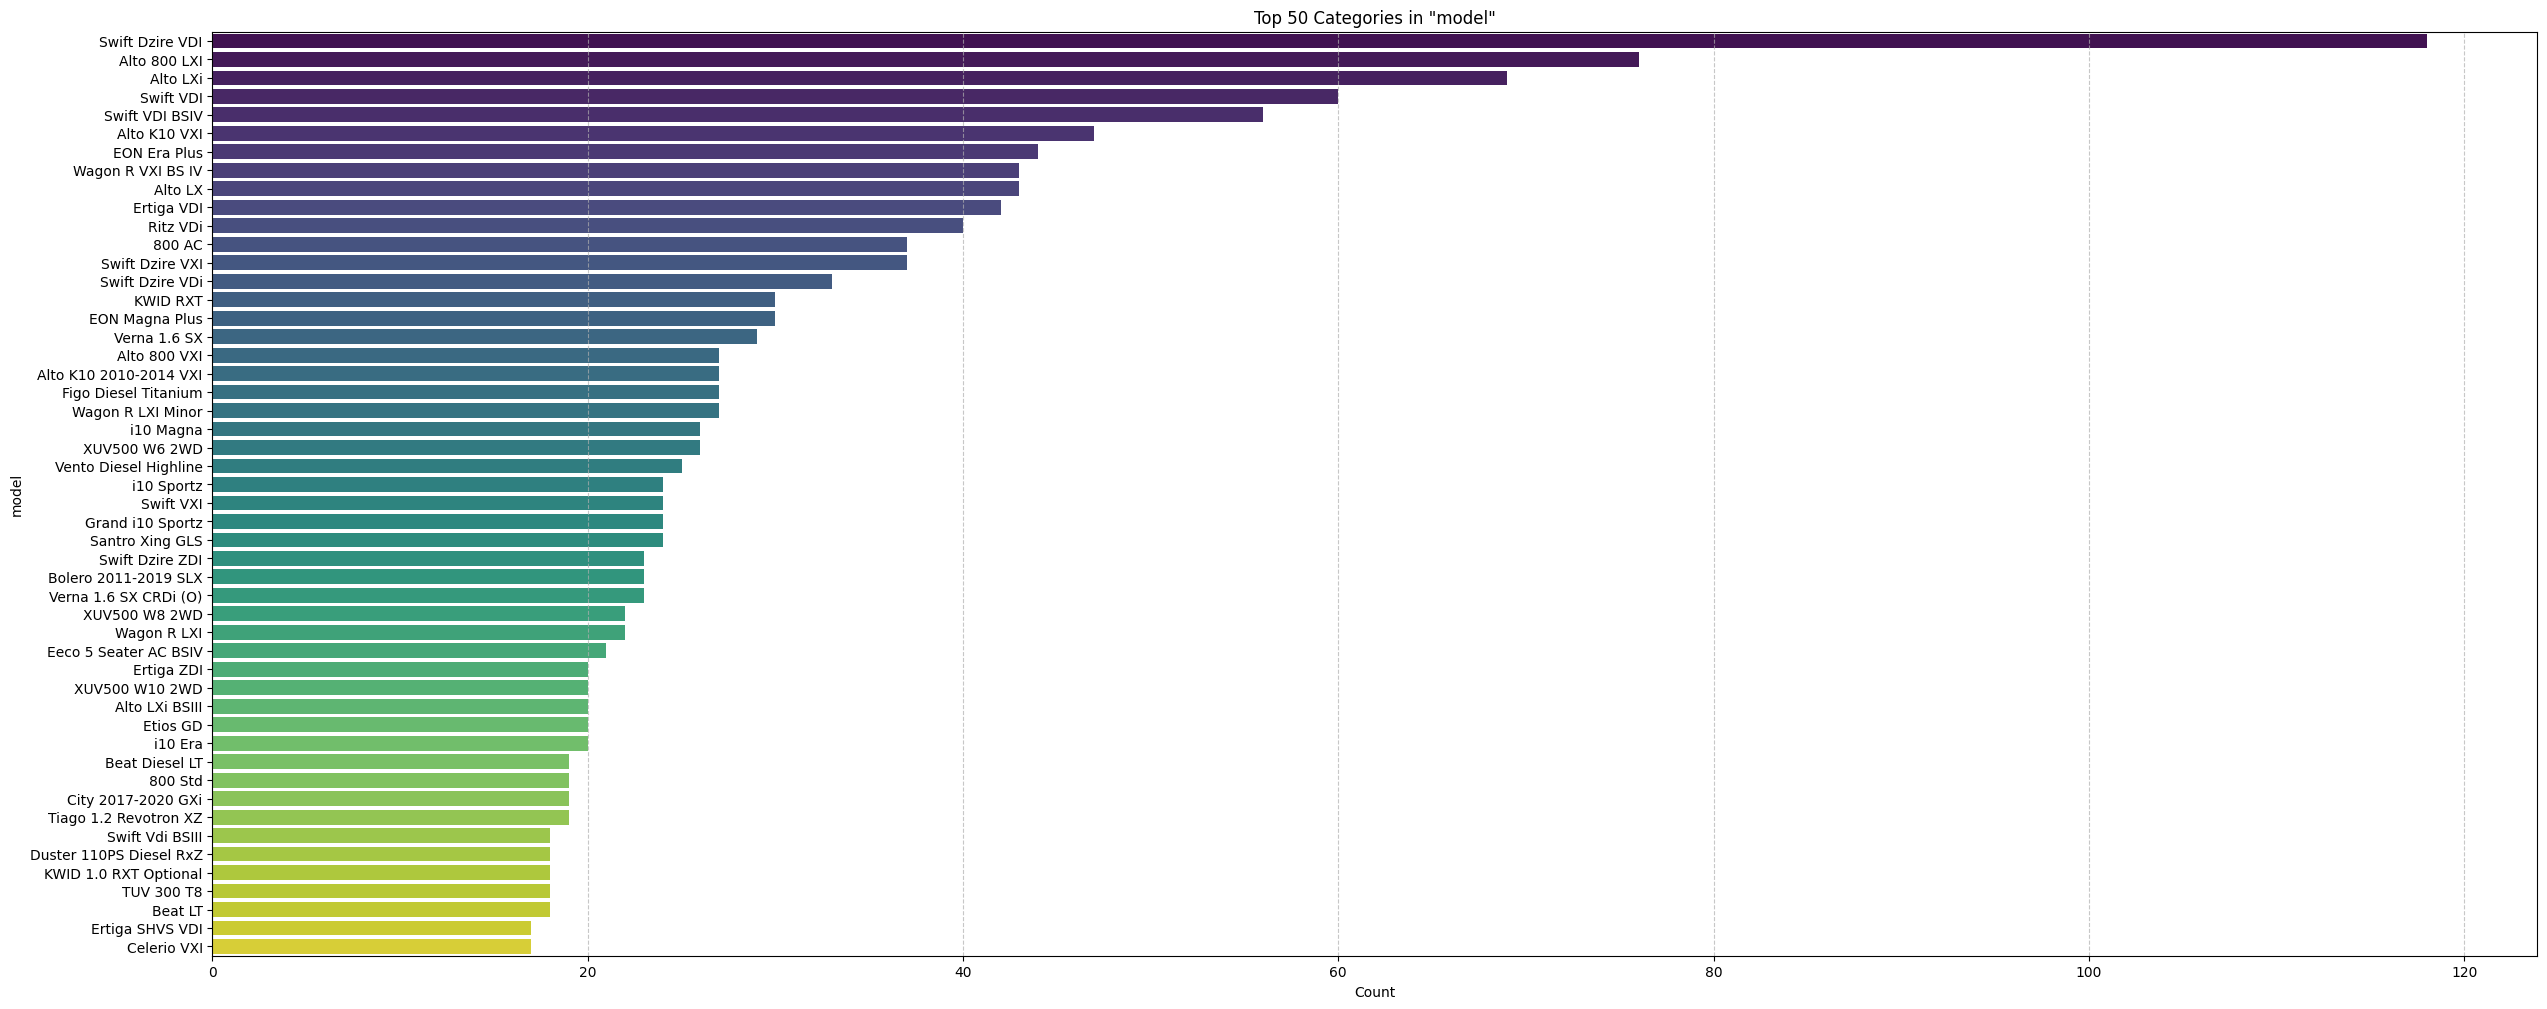

 Unique categories in 'model': 2058
Top 50 values:
model
Swift Dzire VDI            118
Alto 800 LXI                76
Alto LXi                    69
Swift VDI                   60
Swift VDI BSIV              56
Alto K10 VXI                47
EON Era Plus                44
Wagon R VXI BS IV           43
Alto LX                     43
Ertiga VDI                  42
Ritz VDi                    40
800 AC                      37
Swift Dzire VXI             37
Swift Dzire VDi             33
KWID RXT                    30
EON Magna Plus              30
Verna 1.6 SX                29
Alto 800 VXI                27
Alto K10 2010-2014 VXI      27
Figo Diesel Titanium        27
Wagon R LXI Minor           27
i10 Magna                   26
XUV500 W6 2WD               26
Vento Diesel Highline       25
i10 Sportz                  24
Swift VXI                   24
Grand i10 Sportz            24
Santro Xing GLS             24
Swift Dzire ZDI             23
Bolero 2011-2019 SLX        23
Verna 1.6 SX 

In [94]:
print("\n MODEL (Top 30)")
plot_top_categories(df, 'model', top_n=50, figsize=(30, 12))

## **Encoding**

In [95]:
# Get top 14 brands
top_brands = df['brand'].value_counts().head(19).index.tolist()

# Replace non-top brands with 'Other'
df['brand'] = df['brand'].apply(lambda x: x if x in top_brands else 'Other')

# Get top 15 models
top_models = df['model'].value_counts().head(20).index.tolist()

# Replace non-top models with 'Other'
df['model'] = df['model'].apply(lambda x: x if x in top_models else 'Other')

In [96]:
from sklearn.preprocessing import OneHotEncoder
# Columns to one-hot encode
ohe_cols = ['fuel', 'seller_type', 'transmission', 'owner']

# Create encoder
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')  # drop first to avoid multicollinearity

# Fit and transform
ohe_df = pd.DataFrame(
    ohe.fit_transform(df[ohe_cols]),
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df.index
)

# Concatenate with original DataFrame
df = pd.concat([df.drop(columns=ohe_cols), ohe_df], axis=1)

print(" One-Hot Encoded Columns:")
print(ohe.get_feature_names_out(ohe_cols))

 One-Hot Encoded Columns:
['fuel_Diesel' 'fuel_LPG' 'fuel_Petrol' 'seller_type_Individual'
 'seller_type_Trustmark Dealer' 'transmission_Manual'
 'owner_Fourth & Above Owner' 'owner_Second Owner' 'owner_Test Drive Car'
 'owner_Third Owner']


In [97]:
from sklearn.preprocessing import LabelEncoder

# Columns to label encode
le_cols = ['mileage_category', 'brand', 'model']

for col in le_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f" Label Encoding '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

 Label Encoding 'mileage_category': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2), 'Ultra High': np.int64(3), 'Very High': np.int64(4), 'Very Low': np.int64(5)}
 Label Encoding 'brand': {'Audi': np.int64(0), 'BMW': np.int64(1), 'Chevrolet': np.int64(2), 'Datsun': np.int64(3), 'Fiat': np.int64(4), 'Ford': np.int64(5), 'Honda': np.int64(6), 'Hyundai': np.int64(7), 'Jeep': np.int64(8), 'Mahindra': np.int64(9), 'Maruti': np.int64(10), 'Mercedes-Benz': np.int64(11), 'Mitsubishi': np.int64(12), 'Nissan': np.int64(13), 'Other': np.int64(14), 'Renault': np.int64(15), 'Skoda': np.int64(16), 'Tata': np.int64(17), 'Toyota': np.int64(18), 'Volkswagen': np.int64(19)}
 Label Encoding 'model': {'800 AC': np.int64(0), 'Alto 800 LXI': np.int64(1), 'Alto 800 VXI': np.int64(2), 'Alto K10 2010-2014 VXI': np.int64(3), 'Alto K10 VXI': np.int64(4), 'Alto LX': np.int64(5), 'Alto LXi': np.int64(6), 'EON Era Plus': np.int64(7), 'EON Magna Plus': np.int64(8), 'Ertiga VDI': np.int64(9), 'Figo Di

In [98]:
print("\n FINAL DATASET SHAPE:", df.shape)
print("\n DATA TYPES AFTER ENCODING:")
print(df.dtypes)

print("\n FIRST 5 ROWS:")
print(df.head().to_string())


 FINAL DATASET SHAPE: (6926, 37)

 DATA TYPES AFTER ENCODING:
year                              int64
selling_price                     int64
km_driven                         int64
mileage(km/ltr/kg)              float64
engine                          float64
max_power                       float64
seats                           float64
brand                             int64
model                             int64
model_has_VXI                     int64
model_has_VDI                     int64
model_has_EXi                     int64
model_has_Ambition                int64
model_has_Sportz                  int64
model_has_BSIII                   int64
model_has_Di                      int64
model_has_Turbo                   int64
model_has_GT                      int64
model_has_SX                      int64
model_has_LXI                     int64
model_has_ZXI                     int64
model_name_length                 int64
model_word_count                  int64
age              

## **Scaling**

In [99]:
numeric_cols_to_scale = [
    'km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power',
    'model_name_length', 'model_word_count', 'age', 'price_per_km',
    'engine_power_ratio','year','selling_price']


In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform only numeric features (not target)
df_scaled = df.copy()
df_scaled[numeric_cols_to_scale] = scaler.fit_transform(df[numeric_cols_to_scale])

print(" Scaled numeric columns:")
print(numeric_cols_to_scale)

# Verify scaling worked
print("\n Mean and Std Dev after scaling (should be ~0 and ~1):")
for col in numeric_cols_to_scale:
    print(f"{col}: mean={df_scaled[col].mean():.3f}, std={df_scaled[col].std():.3f}")

 Scaled numeric columns:
['km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'model_name_length', 'model_word_count', 'age', 'price_per_km', 'engine_power_ratio', 'year', 'selling_price']

 Mean and Std Dev after scaling (should be ~0 and ~1):
km_driven: mean=-0.000, std=1.000
mileage(km/ltr/kg): mean=-0.000, std=1.000
engine: mean=0.000, std=1.000
max_power: mean=0.000, std=1.000
model_name_length: mean=0.000, std=1.000
model_word_count: mean=-0.000, std=1.000
age: mean=-0.000, std=1.000
price_per_km: mean=-0.000, std=1.000
engine_power_ratio: mean=0.000, std=1.000
year: mean=-0.000, std=1.000
selling_price: mean=-0.000, std=1.000


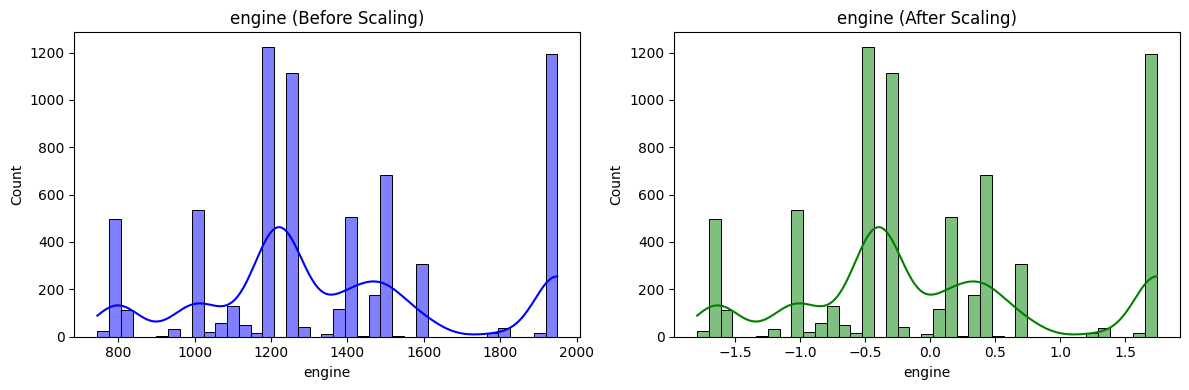

In [101]:
col_to_show = 'engine'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df[col_to_show], kde=True, color='blue')
plt.title(f'{col_to_show} (Before Scaling)')
plt.xlabel(col_to_show)

plt.subplot(1, 2, 2)
sns.histplot(df_scaled[col_to_show], kde=True, color='green')
plt.title(f'{col_to_show} (After Scaling)')
plt.xlabel(col_to_show)

plt.tight_layout()
plt.show()

In [102]:
print(" FINAL DATASET SHAPE:", df_scaled.shape)
print("\n DATA TYPES AFTER SCALING:")
print(df_scaled.dtypes)

print("\n FIRST 5 ROWS:")
print(df_scaled.head().to_string())

 FINAL DATASET SHAPE: (6926, 37)

 DATA TYPES AFTER SCALING:
year                            float64
selling_price                   float64
km_driven                       float64
mileage(km/ltr/kg)              float64
engine                          float64
max_power                       float64
seats                           float64
brand                             int64
model                             int64
model_has_VXI                     int64
model_has_VDI                     int64
model_has_EXi                     int64
model_has_Ambition                int64
model_has_Sportz                  int64
model_has_BSIII                   int64
model_has_Di                      int64
model_has_Turbo                   int64
model_has_GT                      int64
model_has_SX                      int64
model_has_LXI                     int64
model_has_ZXI                     int64
model_name_length               float64
model_word_count                float64
age                

## **Feature Selection**

In [103]:
# Define X (features) and y (targets)
X = df_scaled.drop(columns=['selling_price', 'brand'])  # All features except targets
y_price = df_scaled['selling_price']  # Regression target
y_brand = df_scaled['brand']           # Classification target

print("Feature matrix shape:", X.shape)
print("Price target shape:", y_price.shape)
print("Brand target shape:", y_brand.shape)# Define X (features) and y (targets)


Feature matrix shape: (6926, 35)
Price target shape: (6926,)
Brand target shape: (6926,)


## **FILTER METHOD (For Brand Prediction — Classification)**

In [104]:
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=15)
X_selected_brand = selector.fit_transform(X, y_brand)


selected_features_brand = X.columns[selector.get_support()].tolist()

print(" Top 15 Features for Brand Prediction (Filter Method):")
for i, feat in enumerate(selected_features_brand, 1):
    print(f"{i}. {feat}")


scores = selector.scores_
feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': scores}).sort_values('Score', ascending=False)
print("\n Feature Scores (Mutual Info):")
print(feature_scores.head(10))


X_selected_brand_df = X[selected_features_brand]


df_brand_selected = X_selected_brand_df.copy()
df_brand_selected['brand'] = y_brand.values
df_brand_selected.head()

 Top 15 Features for Brand Prediction (Filter Method):
1. year
2. mileage(km/ltr/kg)
3. engine
4. max_power
5. model
6. model_has_VXI
7. model_has_VDI
8. model_name_length
9. model_word_count
10. age
11. price_per_km
12. mileage_category
13. engine_power_ratio
14. fuel_Diesel
15. fuel_Petrol

 Feature Scores (Mutual Info):
               Feature     Score
24  engine_power_ratio  1.710965
4            max_power  1.602739
2   mileage(km/ltr/kg)  1.592842
3               engine  1.330015
19   model_name_length  0.342877
23    mileage_category  0.216663
6                model  0.186019
27         fuel_Petrol  0.131620
25         fuel_Diesel  0.123799
7        model_has_VXI  0.110262


,year,mileage(km/ltr/kg),engine,max_power,model,model_has_VXI,model_has_VDI,model_name_length,model_word_count,age,price_per_km,mileage_category,engine_power_ratio,fuel_Diesel,fuel_Petrol,brand
0,0.142153,1.004723,-0.316034,-0.457579,14,0,1,-0.398257,-0.560172,-0.137041,-0.723042,0,0.377282,1.0,0.0,10
1,0.142153,0.425430,0.417689,0.676675,12,0,0,0.574796,0.224250,-0.137041,-0.723995,0,-0.666641,1.0,0.0,16
2,-1.819597,-0.456325,0.414754,-0.303886,12,0,0,0.018766,-0.560172,1.896478,-0.921091,2,1.392085,0.0,1.0,6
3,-0.838722,0.902194,0.118330,0.157193,12,0,0,-0.120242,-0.560172,0.879719,-0.856250,0,-0.212976,1.0,0.0,7
4,-1.574378,-0.866444,-0.169289,0.088031,12,1,0,-0.398257,-0.560172,1.642288,-0.925652,2,-0.559416,0.0,1.0,10


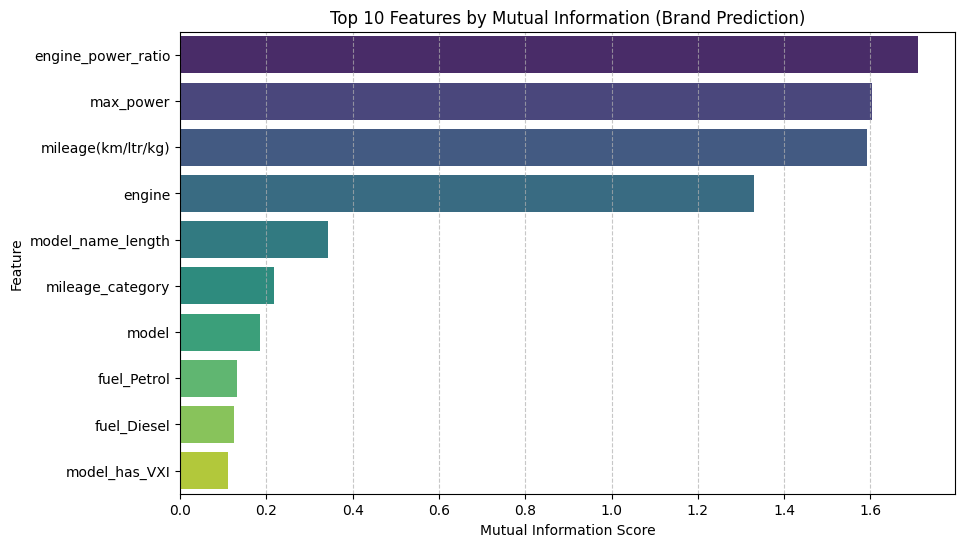

In [105]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(10), palette='viridis')
plt.title('Top 10 Features by Mutual Information (Brand Prediction)')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## **WRAPPER METHOD (For Price Prediction — Regression)**

In [106]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE


rfe = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42),
          n_features_to_select=15, step=1)
X_selected_price = rfe.fit_transform(X, y_price)


selected_features_price = X.columns[rfe.support_].tolist()
print(" Top 15 Features (RFE with Random Forest):")
for i, feat in enumerate(selected_features_price, 1):
    print(f"{i}. {feat}")


ranking = rfe.ranking_
feature_ranking = pd.DataFrame({'Feature': X.columns, 'Rank': ranking}).sort_values('Rank')
print("\n Feature Ranking (RFE with Random Forest):")
print(feature_ranking.head(10))

# Create a new DataFrame containing only the top 15 RFE-selected features for price
X_selected_price_df = X[selected_features_price]

# Optional: Add the target 'selling_price' back to make a complete modeling dataset
df_price_selected = X_selected_price_df.copy()
df_price_selected['selling_price'] = y_price.values  # or just y_price if it's a pandas Series




 Top 15 Features (RFE with Random Forest):
1. year
2. km_driven
3. mileage(km/ltr/kg)
4. engine
5. max_power
6. model_name_length
7. model_word_count
8. age
9. price_per_km
10. mileage_category
11. engine_power_ratio
12. fuel_Diesel
13. fuel_Petrol
14. seller_type_Individual
15. transmission_Manual

 Feature Ranking (RFE with Random Forest):
                   Feature  Rank
0                     year     1
1                km_driven     1
2       mileage(km/ltr/kg)     1
3                   engine     1
4                max_power     1
21                     age     1
28  seller_type_Individual     1
30     transmission_Manual     1
24      engine_power_ratio     1
25             fuel_Diesel     1


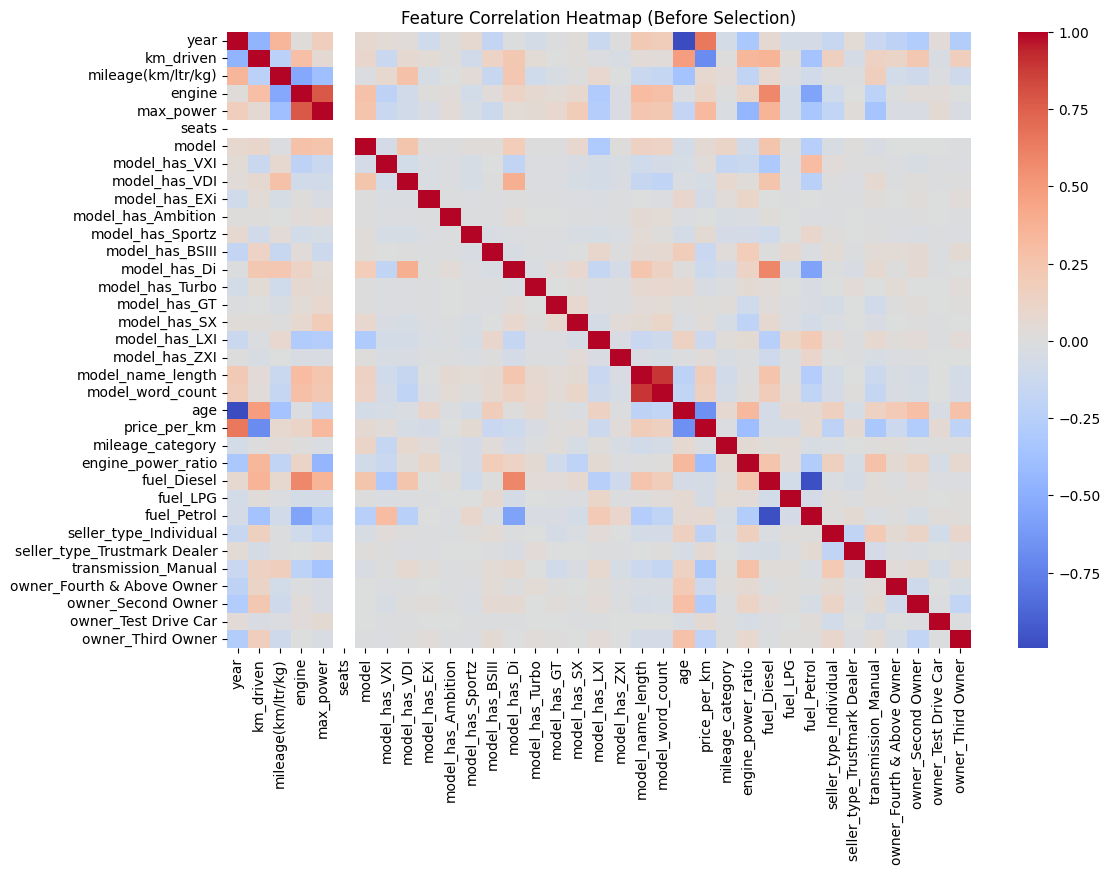

In [107]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap (Before Selection)')
plt.show()

## **EMBEDDED METHOD (For Both Targets — Tree-Based Models)**

In [108]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# For Brand (Classification)
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X, y_brand)
importance_brand = rfc.feature_importances_

# For Price (Regression)
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X, y_price)
importance_price = rfr.feature_importances_

# Create DataFrames
feat_imp_brand = pd.DataFrame({'Feature': X.columns, 'Importance': importance_brand}).sort_values('Importance', ascending=False)
feat_imp_price = pd.DataFrame({'Feature': X.columns, 'Importance': importance_price}).sort_values('Importance', ascending=False)

print(" Top 10 Features by Random Forest Importance (Brand):")
print(feat_imp_brand.head(10))


print("\n Top 10 Features by Random Forest Importance (Price):")
print(feat_imp_price.head(10))

# Get the top 10 feature names
top10_features_brand = feat_imp_brand.head(10)['Feature'].tolist()
top10_features_price = feat_imp_price.head(10)['Feature'].tolist()

# Create new dataframes with the top 10 features and the target variable
df_brand_top10 = X[top10_features_brand].copy()
df_brand_top10['brand'] = y_brand

df_price_top10 = X[top10_features_price].copy()
df_price_top10['selling_price'] = y_price

print("\nShape of df_brand_top10:", df_brand_top10.shape)
print("Shape of df_price_top10:", df_price_top10.shape)

print("\nFirst 5 rows of df_brand_top10:")
print(df_brand_top10.head().to_string())

print("\nFirst 5 rows of df_price_top10:")
print(df_price_top10.head().to_string())

 Top 10 Features by Random Forest Importance (Brand):
               Feature  Importance
3               engine    0.148288
4            max_power    0.137736
24  engine_power_ratio    0.137687
2   mileage(km/ltr/kg)    0.116010
19   model_name_length    0.063962
20    model_word_count    0.035971
23    mileage_category    0.034822
22        price_per_km    0.033242
7        model_has_VXI    0.033030
13        model_has_Di    0.031407

 Top 10 Features by Random Forest Importance (Price):
               Feature  Importance
22        price_per_km    0.574526
4            max_power    0.228410
1            km_driven    0.112496
3               engine    0.038327
0                 year    0.012795
21                 age    0.010664
2   mileage(km/ltr/kg)    0.005588
24  engine_power_ratio    0.004819
19   model_name_length    0.003671
25         fuel_Diesel    0.003110

Shape of df_brand_top10: (6926, 11)
Shape of df_price_top10: (6926, 11)

First 5 rows of df_brand_top10:
     engine  ma

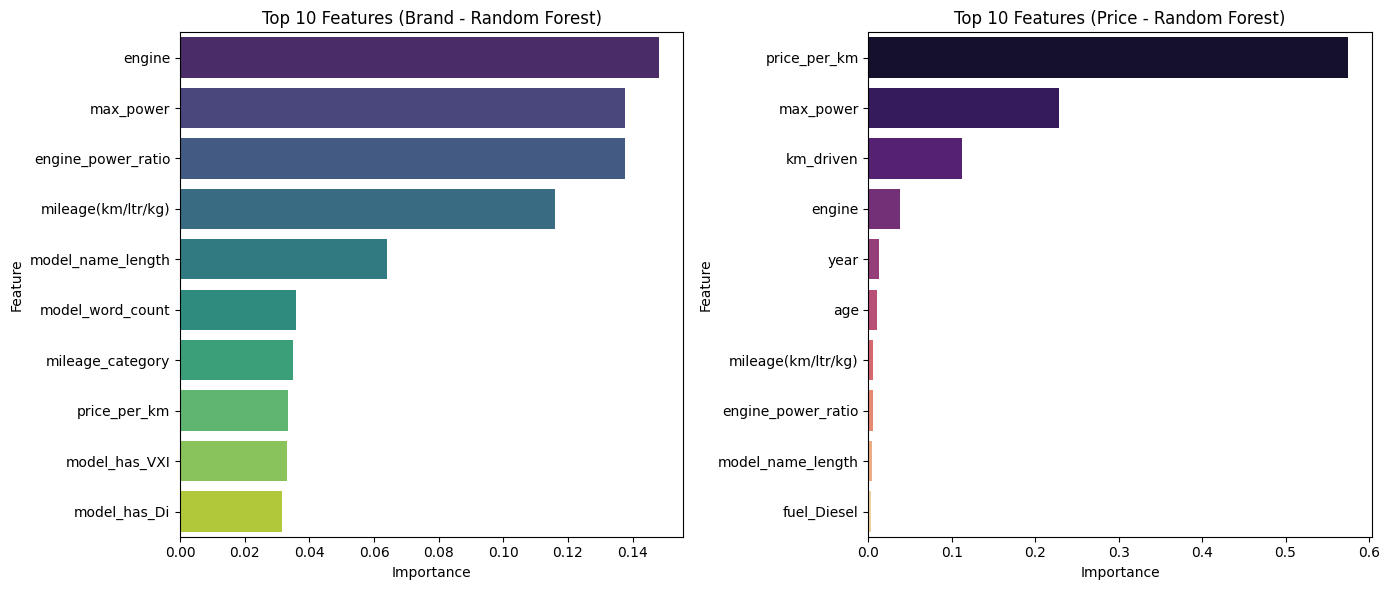

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Brand
sns.barplot(x='Importance', y='Feature', data=feat_imp_brand.head(10), ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Features (Brand - Random Forest)')
axes[0].set_xlabel('Importance')

# Price
sns.barplot(x='Importance', y='Feature', data=feat_imp_price.head(10), ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Features (Price - Random Forest)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## **Apply Feature Extraction Techniques**

## **METHOD 1: PCA (For Price Prediction — Regression)**

In [110]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [111]:
# Define X (features) and y (targets)
X = df_scaled.drop(columns=['selling_price', 'brand'])  # All features except targets
y_price = df_scaled['selling_price']  # Regression target
y_brand = df_scaled['brand']           # Classification target

print("Feature matrix shape:", X.shape)
print("Price target shape:", y_price.shape)
print("Brand target shape:", y_brand.shape)

Feature matrix shape: (6926, 35)
Price target shape: (6926,)
Brand target shape: (6926,)


## **Feature Extraction with PCA for Price Prediction**


=== FEATURE EXTRACTION WITH PCA FOR PRICE PREDICTION ===
Original feature count for Price Prediction: 35
Components kept after PCA (for 95% variance): 10
Explained variance retained: 0.9511

Eigenvalues (Explained Variance per PC) for Price Prediction:
[5.89952977 3.4738958  2.51066015 1.53429991 1.43237309 1.02920098
 0.84146435 0.47022936 0.19941879 0.18227524]

Eigenvectors (PCA components matrix) for Price Prediction:
      year  km_driven  mileage(km/ltr/kg)  engine  max_power  seats  model  \
PC1  0.071      0.036              -0.032   0.178      0.175   -0.0  0.936   
PC2 -0.473      0.387              -0.183   0.045     -0.115   -0.0  0.129   
PC3 -0.024      0.181              -0.382   0.462      0.376    0.0 -0.275   
PC4 -0.080     -0.104              -0.304   0.268      0.436    0.0 -0.079   
PC5  0.056     -0.012               0.089  -0.006     -0.133   -0.0 -0.094   

     model_has_VXI  model_has_VDI  model_has_EXi  ...  fuel_Diesel  fuel_LPG  \
PC1         -0.011      

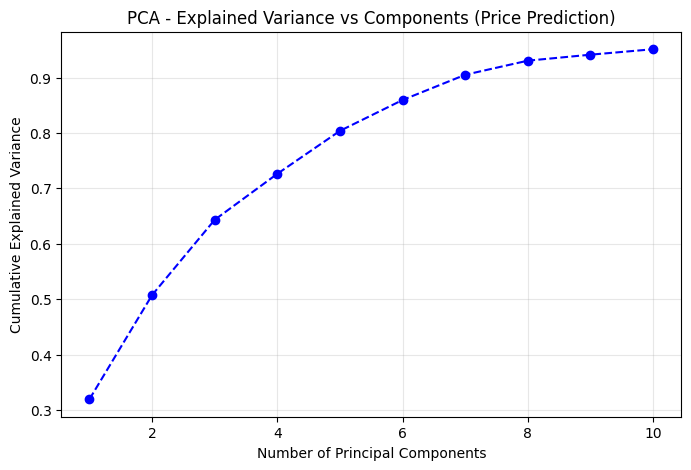

In [112]:
print("\n=== FEATURE EXTRACTION WITH PCA FOR PRICE PREDICTION ===")

# Apply PCA to retain 95% of variance
pca_price = PCA(n_components=0.95, svd_solver="full", random_state=42)
X_price_pca = pca_price.fit_transform(X)  # X_price is assumed to be pre-scaled

print("Original feature count for Price Prediction:", X.shape[1])
print("Components kept after PCA (for 95% variance):", pca_price.n_components_)
print("Explained variance retained:", round(pca_price.explained_variance_ratio_.sum(), 4))

# Eigenvalues (Explained Variance per PC)
print("\nEigenvalues (Explained Variance per PC) for Price Prediction:")
print(pca_price.explained_variance_)

# Eigenvectors (PCA components matrix)
pca_components_df_price = pd.DataFrame(
    pca_price.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(pca_price.n_components_)]
)
print("\nEigenvectors (PCA components matrix) for Price Prediction:")
print(pca_components_df_price.round(3).head(5))  # Show top 5 PCs for brevity

# PCA-transformed dataset
X_price_pca_df = pd.DataFrame(
    X_price_pca,
    columns=[f"PC{i+1}" for i in range(pca_price.n_components_)],
    index=X.index
)
print("\nPCA-transformed dataset for Price Prediction (first 5 rows):")
print(X_price_pca_df.head(5))

# Variance explained by each PC
explained_var_price = pd.Series(
    pca_price.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(pca_price.n_components_)]
)
print("\nVariance explained by each PC for Price Prediction:")
print(explained_var_price.round(4))

# Cumulative Variance Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_var_price)+1), explained_var_price.cumsum(), marker="o", linestyle="--", color='blue')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance vs Components (Price Prediction)")
plt.grid(True, alpha=0.3)
plt.show()

## **Feature Extraction with PCA for Brand Prediction**


=== FEATURE EXTRACTION WITH PCA FOR BRAND PREDICTION ===
Original feature count for Brand Prediction: 35
Components kept after PCA (for 95% variance): 10
Explained variance retained: 0.9511

Eigenvalues (Explained Variance per PC) for Brand Prediction:
[5.89952977 3.4738958  2.51066015 1.53429991 1.43237309 1.02920098
 0.84146435 0.47022936 0.19941879 0.18227524]

Eigenvectors (PCA components matrix) for Brand Prediction:
      year  km_driven  mileage(km/ltr/kg)  engine  max_power  seats  model  \
PC1  0.071      0.036              -0.032   0.178      0.175   -0.0  0.936   
PC2 -0.473      0.387              -0.183   0.045     -0.115   -0.0  0.129   
PC3 -0.024      0.181              -0.382   0.462      0.376    0.0 -0.275   
PC4 -0.080     -0.104              -0.304   0.268      0.436    0.0 -0.079   
PC5  0.056     -0.012               0.089  -0.006     -0.133   -0.0 -0.094   

     model_has_VXI  model_has_VDI  model_has_EXi  ...  fuel_Diesel  fuel_LPG  \
PC1         -0.011      

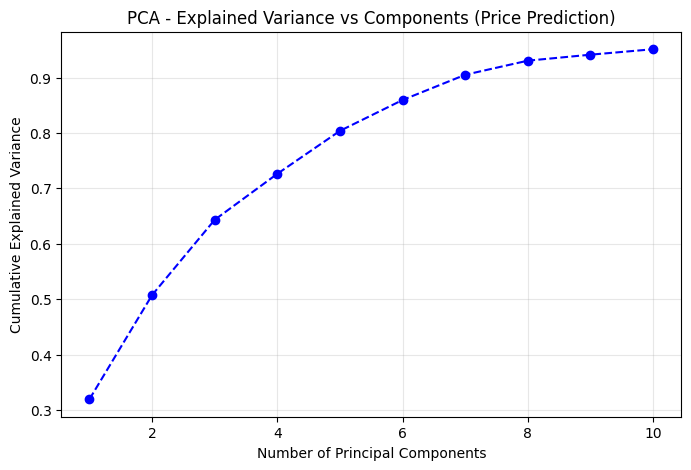

In [113]:
print("\n=== FEATURE EXTRACTION WITH PCA FOR BRAND PREDICTION ===")

# Apply PCA to retain 95% of variance
pca_brand = PCA(n_components=0.95, svd_solver="full", random_state=42)
X_brand_pca = pca_brand.fit_transform(X)  # X_brand is assumed to be pre-scaled

print("Original feature count for Brand Prediction:", X.shape[1])
print("Components kept after PCA (for 95% variance):", pca_brand.n_components_)
print("Explained variance retained:", round(pca_brand.explained_variance_ratio_.sum(), 4))

# Eigenvalues (Explained Variance per PC)
print("\nEigenvalues (Explained Variance per PC) for Brand Prediction:")
print(pca_brand.explained_variance_)

# Eigenvectors (PCA components matrix)
pca_components_df_brand = pd.DataFrame(
    pca_brand.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(pca_brand.n_components_)]
)
print("\nEigenvectors (PCA components matrix) for Brand Prediction:")
print(pca_components_df_brand.round(3).head(5))  # Show top 5 PCs for brevity

# PCA-transformed dataset
X_brand_pca_df = pd.DataFrame(
    X_brand_pca,
    columns=[f"PC{i+1}" for i in range(pca_brand.n_components_)],
    index=X.index
)
print("\nPCA-transformed dataset for Brand Prediction (first 5 rows):")
print(X_brand_pca_df.head(5))

# Variance explained by each PC
explained_var_brand = pd.Series(
    pca_brand.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(pca_brand.n_components_)]
)
print("\nVariance explained by each PC for Brand Prediction:")
print(explained_var_brand.round(4))


# Cumulative Variance Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_var_brand)+1), explained_var_brand.cumsum(), marker="o", linestyle="--", color='blue')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance vs Components (Price Prediction)")
plt.grid(True, alpha=0.3)
plt.show()

In [114]:
# For Price Prediction: Add target 'selling_price'
price_final = X_price_pca_df.copy()
price_final['selling_price'] = y_price.reset_index(drop=True)  # Ensure index alignment

# For Brand Prediction: Add target 'brand_encoded'
brand_final = X_brand_pca_df.copy()
brand_final['brand_encoded'] = y_brand.reset_index(drop=True)  # Ensure index alignment

print("Final datasets created:")
print(f"Price Dataset Shape: {price_final.shape}")
print(f"Brand Dataset Shape: {brand_final.shape}")

Final datasets created:
Price Dataset Shape: (6926, 11)
Brand Dataset Shape: (6926, 11)


In [115]:
import os

# Create the directory if it doesn't exist
output_dir = '/content/drive/MyDrive/outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save as CSV (often preferred for ML pipelines)
price_final.to_csv(os.path.join(output_dir, 'price_prediction_features.csv'), index=False)
brand_final.to_csv(os.path.join(output_dir, 'brand_prediction_features.csv'), index=False)

print("Also saved as CSV for easy model training!")

Also saved as CSV for easy model training!


In [116]:
# Convert CSV to Excel (.xlsx)
price_final.to_excel('/content/drive/MyDrive/outputs/price_prediction_features.xlsx', index=False)
brand_final.to_excel('/content/drive/MyDrive/outputs/brand_prediction_features.xlsx', index=False)

print("Saved as Excel (.xlsx) files!")

# Optional: Download directly to your local machine from Colab
from google.colab import files

files.download('/content/drive/MyDrive/outputs/price_prediction_features.xlsx')
files.download('/content/drive/MyDrive/outputs/brand_prediction_features.xlsx')

Saved as Excel (.xlsx) files!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **SVM - (Hettiarachchige H.S)**

In [160]:
# Import libraries for SVM (regressor and classifier), metrics, cross-validation, and visualizations
# This ensures we have all tools for training, evaluation, and plotting for both price and brand prediction
from sklearn.svm import SVR, SVC
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, validation_curve, train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

Load Datasets and Prepare Data for Both Price and Brand Prediction

In [161]:
# Load both datasets (price and brand features) and prepare features (X) and targets (y_price, y_brand)
# Apply preprocessing: SMOTE for brand (classification), no SMOTE for price (regression), scaling for both, separate train/test splits
price_df = pd.read_excel('/content/drive/MyDrive/outputs/price_prediction_features.xlsx')  # Adjust path if needed
brand_df = pd.read_excel('/content/drive/MyDrive/outputs/brand_prediction_features.xlsx')  # Adjust path if needed

X_price = price_df.iloc[:, :-1]  # PC1 to PC11 for price
y_price = price_df['selling_price']

X_brand = brand_df.iloc[:, :-1]  # PC1 to PC11 for brand (same features)
y_brand = brand_df['brand_encoded']

# Split for price (no SMOTE)
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(X_price, y_price, test_size=0.2, random_state=42)

# Apply SMOTE and split for brand
smote = SMOTE(random_state=42)
X_brand_resampled, y_brand_resampled = smote.fit_resample(X_brand, y_brand)
X_train_brand, X_test_brand, y_train_brand, y_test_brand = train_test_split(X_brand_resampled, y_brand_resampled, test_size=0.2, random_state=42)

# Scale features separately (to avoid data leakage)
scaler_price = StandardScaler()
X_train_price = scaler_price.fit_transform(X_train_price)
X_test_price = scaler_price.transform(X_test_price)

scaler_brand = StandardScaler()
X_train_brand = scaler_brand.fit_transform(X_train_brand)
X_test_brand = scaler_brand.transform(X_test_brand)

# **Model 1**

Build and Train Model_1 (Baseline for Both Price and Brand)

In [166]:
# Build baseline SVC for brand with default parameters
# This serves as a starting point for brand prediction without tuning
svm_1 = SVC()
svm_1.fit(X_train_brand, y_train_brand)

y_pred_brand_1 = svm_1.predict(X_test_brand)

Calculate and Display Performance Metrics for Model_1 (Both Price and Brand)

In [167]:
# Calculate metrics for price (MSE, MAE, R2) and brand (Accuracy, Precision, Recall, F1)
mse_1 = mean_squared_error(y_test_price, y_pred_price_1)
mae_1 = mean_absolute_error(y_test_price, y_pred_price_1)
r2_1 = r2_score(y_test_price, y_pred_price_1)

accuracy_1 = accuracy_score(y_test_brand, y_pred_brand_1)
precision_1 = precision_score(y_test_brand, y_pred_brand_1, average='weighted')
recall_1 = recall_score(y_test_brand, y_pred_brand_1, average='weighted')
f1_1 = f1_score(y_test_brand, y_pred_brand_1, average='weighted')

print("Model_1 (Baseline) Metrics for Price:")
print(f"Mean Squared Error: {mse_1:.4f}")
print(f"Mean Absolute Error: {mae_1:.4f}")
print(f"R² Score: {r2_1:.4f}")

print("\nModel_1 (Baseline) Metrics for Brand:")
print(f"Accuracy: {accuracy_1:.4f}")
print(f"Precision: {precision_1:.4f}")
print(f"Recall: {recall_1:.4f}")
print(f"F1 Score: {f1_1:.4f}")

Model_1 (Baseline) Metrics for Price:
Mean Squared Error: 0.0620
Mean Absolute Error: 0.1730
R² Score: 0.9350

Model_1 (Baseline) Metrics for Brand:
Accuracy: 0.8997
Precision: 0.8991
Recall: 0.8997
F1 Score: 0.8978


Display Reports and Plots for Model_1 (Both Price and Brand)

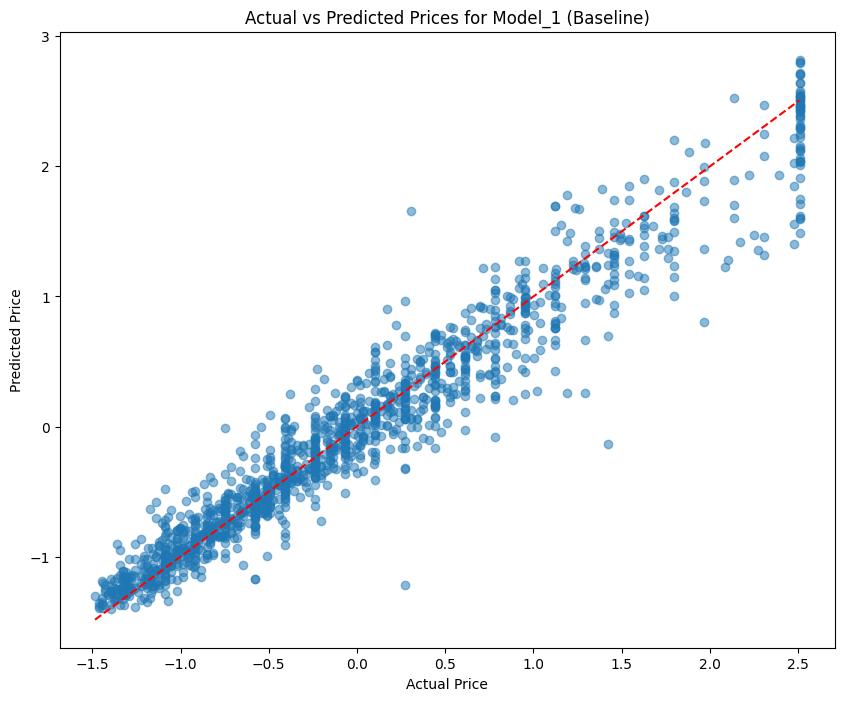

Classification Report for Model_1 Brand:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       448
           1       0.97      0.95      0.96       396
           2       0.89      0.92      0.90       468
           3       0.96      1.00      0.98       418
           4       0.87      1.00      0.93       396
           5       0.79      0.80      0.80       429
           6       0.88      0.92      0.90       443
           7       0.77      0.66      0.71       445
           8       0.93      1.00      0.96       440
           9       0.91      0.89      0.90       457
          10       0.89      0.78      0.83       443
          11       0.95      0.99      0.97       411
          12       0.95      1.00      0.97       427
          13       0.88      0.98      0.93       440
          14       0.92      0.92      0.92       426
          15       0.97      0.91      0.94       428
          16       0.87      0.92      0

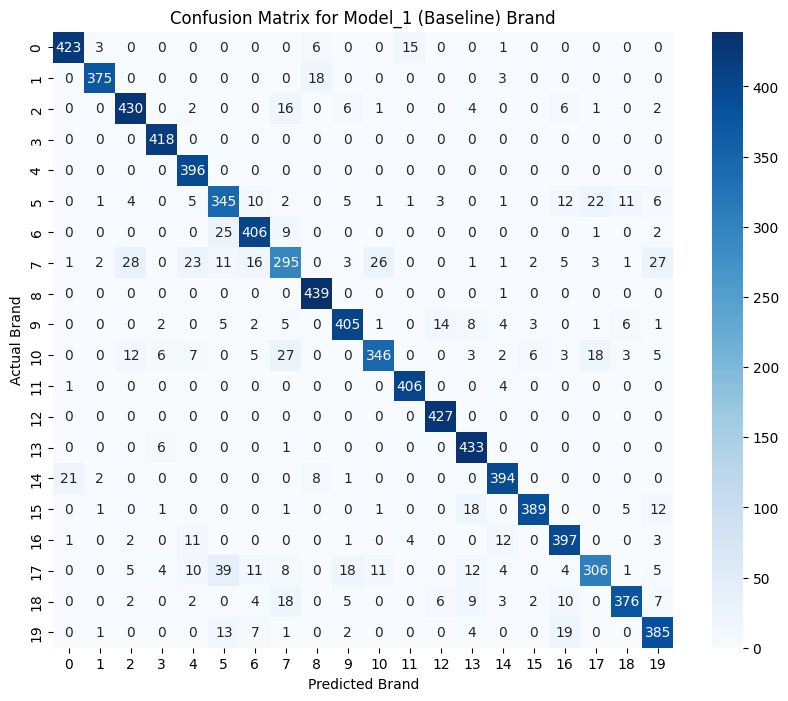

In [168]:
# For price: Plot actual vs predicted; For brand: Classification report and confusion matrix
plt.figure(figsize=(10, 8))
plt.scatter(y_test_price, y_pred_price_1, alpha=0.5)
plt.plot([y_test_price.min(), y_test_price.max()], [y_test_price.min(), y_test_price.max()], 'r--')
plt.title('Actual vs Predicted Prices for Model_1 (Baseline)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

print("Classification Report for Model_1 Brand:")
print(classification_report(y_test_brand, y_pred_brand_1))

cm_1 = confusion_matrix(y_test_brand, y_pred_brand_1)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Model_1 (Baseline) Brand')
plt.xlabel('Predicted Brand')
plt.ylabel('Actual Brand')
plt.show()

Perform K-Fold Cross Validation for Model_1 (Both Price and Brand)

In [171]:
# 5-fold cross-validation for price (R2) and brand (accuracy)
cv_scores_price_1 = cross_val_score(svr_1, X_train_price, y_train_price, cv=5, scoring='r2')
cv_scores_brand_1 = cross_val_score(svm_1, X_train_brand, y_train_brand, cv=5, scoring='accuracy')

print("Model_1 Cross-Validation for Price: Mean R2 = {:.4f}, Std = {:.4f}".format(cv_scores_price_1.mean(), cv_scores_price_1.std()))
print("Model_1 Cross-Validation for Brand: Mean Accuracy = {:.4f}, Std = {:.4f}".format(cv_scores_brand_1.mean(), cv_scores_brand_1.std()))

Model_1 Cross-Validation for Price: Mean R2 = 0.9395, Std = 0.0040
Model_1 Cross-Validation for Brand: Mean Accuracy = 0.8858, Std = 0.0031


# **Model 2**

Build and Train Model_2 (Tuned Level 1 for Both Price and Brand)

In [175]:
# Tune with C=10 for both SVR (price) and SVC (brand)
svr_2 = SVR(C=10)
svr_2.fit(X_train_price, y_train_price)
y_pred_price_2 = svr_2.predict(X_test_price)

svm_2 = SVC(C=10)
svm_2.fit(X_train_brand, y_train_brand)
y_pred_brand_2 = svm_2.predict(X_test_brand)

Calculate and Display Performance Metrics for Model_2 (Both Price and Brand)

In [176]:
mse_2 = mean_squared_error(y_test_price, y_pred_price_2)
mae_2 = mean_absolute_error(y_test_price, y_pred_price_2)
r2_2 = r2_score(y_test_price, y_pred_price_2)

accuracy_2 = accuracy_score(y_test_brand, y_pred_brand_2)
precision_2 = precision_score(y_test_brand, y_pred_brand_2, average='weighted')
recall_2 = recall_score(y_test_brand, y_pred_brand_2, average='weighted')
f1_2 = f1_score(y_test_brand, y_pred_brand_2, average='weighted')

print("Model_2 (Tuned Level 1) Metrics for Price:")
print(f"Mean Squared Error: {mse_2:.4f}")
print(f"Mean Absolute Error: {mae_2:.4f}")
print(f"R² Score: {r2_2:.4f}")

print("\nModel_2 (Tuned Level 1) Metrics for Brand:")
print(f"Accuracy: {accuracy_2:.4f}")
print(f"Precision: {precision_2:.4f}")
print(f"Recall: {recall_2:.4f}")
print(f"F1 Score: {f1_2:.4f}")

Model_2 (Tuned Level 1) Metrics for Price:
Mean Squared Error: 0.0493
Mean Absolute Error: 0.1472
R² Score: 0.9484

Model_2 (Tuned Level 1) Metrics for Brand:
Accuracy: 0.9687
Precision: 0.9687
Recall: 0.9687
F1 Score: 0.9685


Display Reports and Plots for Model_2 (Both Price and Brand)

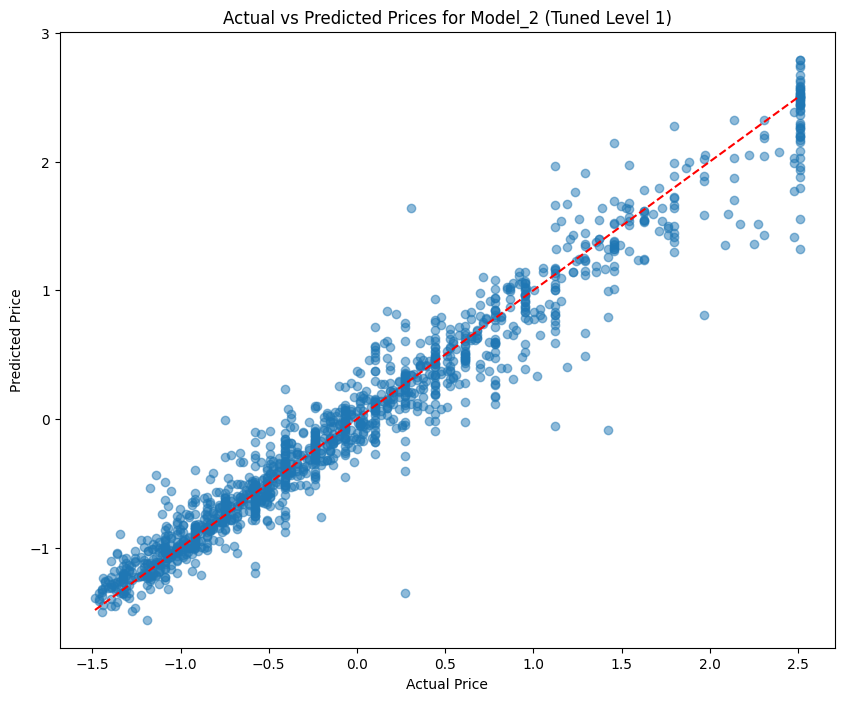

Classification Report for Model_2 Brand:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       448
           1       0.99      0.99      0.99       396
           2       0.97      0.99      0.98       468
           3       0.99      1.00      1.00       418
           4       0.98      1.00      0.99       396
           5       0.92      0.91      0.92       429
           6       0.95      0.96      0.96       443
           7       0.90      0.89      0.89       445
           8       1.00      1.00      1.00       440
           9       1.00      0.97      0.98       457
          10       0.95      0.87      0.91       443
          11       1.00      0.99      1.00       411
          12       0.99      1.00      1.00       427
          13       0.97      1.00      0.98       440
          14       1.00      0.99      0.99       426
          15       0.98      0.98      0.98       428
          16       0.95      1.00      0

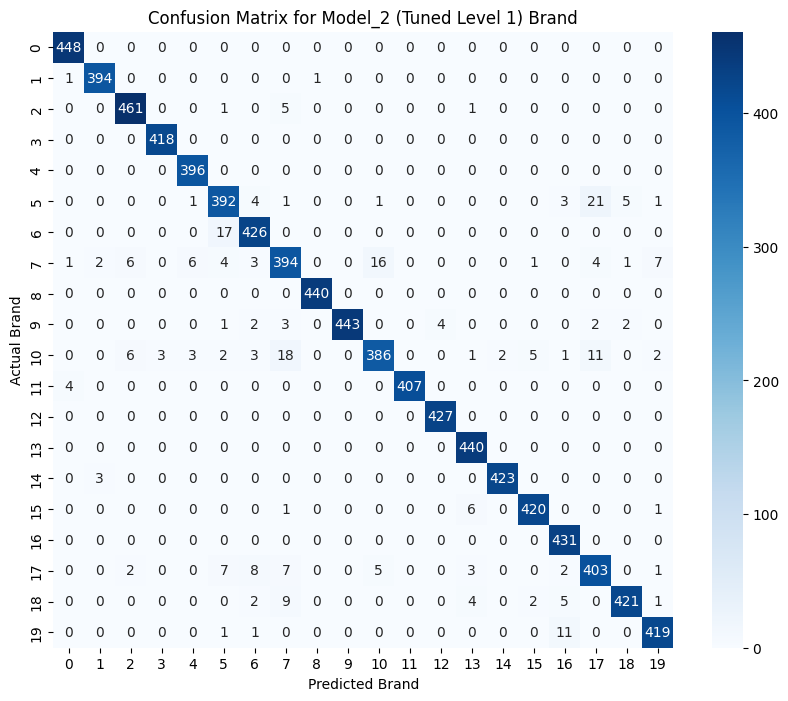

In [177]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test_price, y_pred_price_2, alpha=0.5)
plt.plot([y_test_price.min(), y_test_price.max()], [y_test_price.min(), y_test_price.max()], 'r--')
plt.title('Actual vs Predicted Prices for Model_2 (Tuned Level 1)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

print("Classification Report for Model_2 Brand:")
print(classification_report(y_test_brand, y_pred_brand_2))

cm_2 = confusion_matrix(y_test_brand, y_pred_brand_2)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Model_2 (Tuned Level 1) Brand')
plt.xlabel('Predicted Brand')
plt.ylabel('Actual Brand')
plt.show()

Perform K-Fold Cross Validation for Model_2 (Both Price and Brand)

In [178]:
cv_scores_price_2 = cross_val_score(svr_2, X_train_price, y_train_price, cv=5, scoring='r2')
cv_scores_brand_2 = cross_val_score(svm_2, X_train_brand, y_train_brand, cv=5, scoring='accuracy')

print("Model_2 Cross-Validation for Price: Mean R2 = {:.4f}, Std = {:.4f}".format(cv_scores_price_2.mean(), cv_scores_price_2.std()))
print("Model_2 Cross-Validation for Brand: Mean Accuracy = {:.4f}, Std = {:.4f}".format(cv_scores_brand_2.mean(), cv_scores_brand_2.std()))

Model_2 Cross-Validation for Price: Mean R2 = 0.9524, Std = 0.0034
Model_2 Cross-Validation for Brand: Mean Accuracy = 0.9622, Std = 0.0031


# **Model 3**

Build and Train Model_3 (Tuned Level 2 for Both Price and Brand)

In [180]:
# Tune to linear kernel, C=1 for both
svr_3 = SVR(kernel='linear', C=1)
svr_3.fit(X_train_price, y_train_price)
y_pred_price_3 = svr_3.predict(X_test_price)

svm_3 = SVC(kernel='linear', C=1)
svm_3.fit(X_train_brand, y_train_brand)
y_pred_brand_3 = svm_3.predict(X_test_brand)

Cell 13

Calculate and Display Performance Metrics for Model_3 (Both Price and Brand)

In [181]:
mse_3 = mean_squared_error(y_test_price, y_pred_price_3)
mae_3 = mean_absolute_error(y_test_price, y_pred_price_3)
r2_3 = r2_score(y_test_price, y_pred_price_3)

accuracy_3 = accuracy_score(y_test_brand, y_pred_brand_3)
precision_3 = precision_score(y_test_brand, y_pred_brand_3, average='weighted')
recall_3 = recall_score(y_test_brand, y_pred_brand_3, average='weighted')
f1_3 = f1_score(y_test_brand, y_pred_brand_3, average='weighted')

print("Model_3 (Tuned Level 2) Metrics for Price:")
print(f"Mean Squared Error: {mse_3:.4f}")
print(f"Mean Absolute Error: {mae_3:.4f}")
print(f"R² Score: {r2_3:.4f}")

print("\nModel_3 (Tuned Level 2) Metrics for Brand:")
print(f"Accuracy: {accuracy_3:.4f}")
print(f"Precision: {precision_3:.4f}")
print(f"Recall: {recall_3:.4f}")
print(f"F1 Score: {f1_3:.4f}")

Model_3 (Tuned Level 2) Metrics for Price:
Mean Squared Error: 0.1941
Mean Absolute Error: 0.3394
R² Score: 0.7968

Model_3 (Tuned Level 2) Metrics for Brand:
Accuracy: 0.5815
Precision: 0.5793
Recall: 0.5815
F1 Score: 0.5653


Display Reports and Plots for Model_3 (Both Price and Brand)

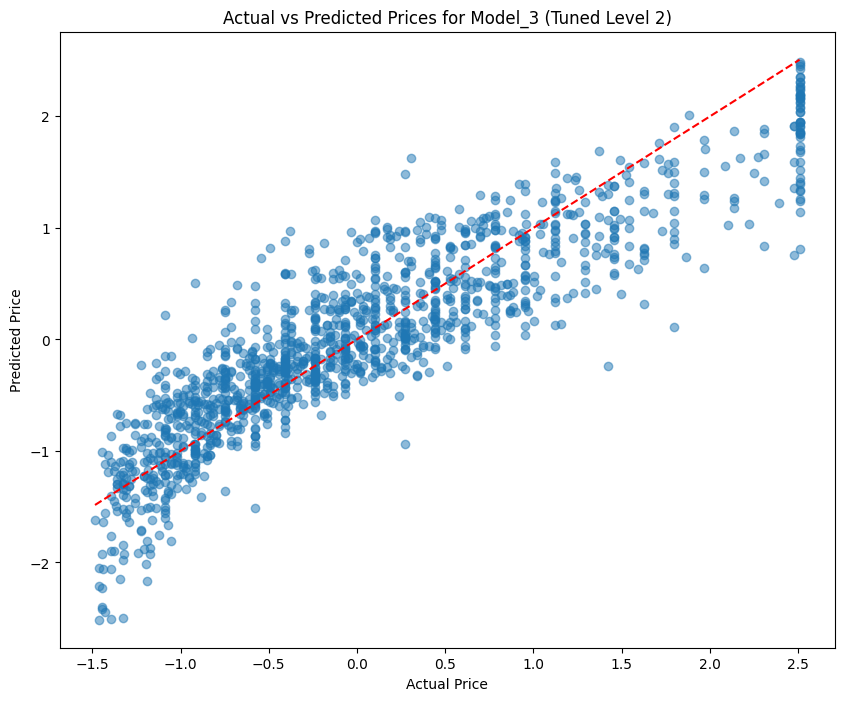

Classification Report for Model_3 Brand:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70       448
           1       0.76      0.60      0.67       396
           2       0.41      0.59      0.48       468
           3       0.83      0.90      0.87       418
           4       0.53      0.74      0.62       396
           5       0.39      0.52      0.45       429
           6       0.61      0.67      0.64       443
           7       0.25      0.22      0.24       445
           8       0.71      0.92      0.80       440
           9       0.68      0.58      0.63       457
          10       0.64      0.49      0.56       443
          11       0.66      0.82      0.73       411
          12       0.71      1.00      0.83       427
          13       0.59      0.73      0.65       440
          14       0.42      0.35      0.38       426
          15       0.45      0.48      0.47       428
          16       0.66      0.50      0

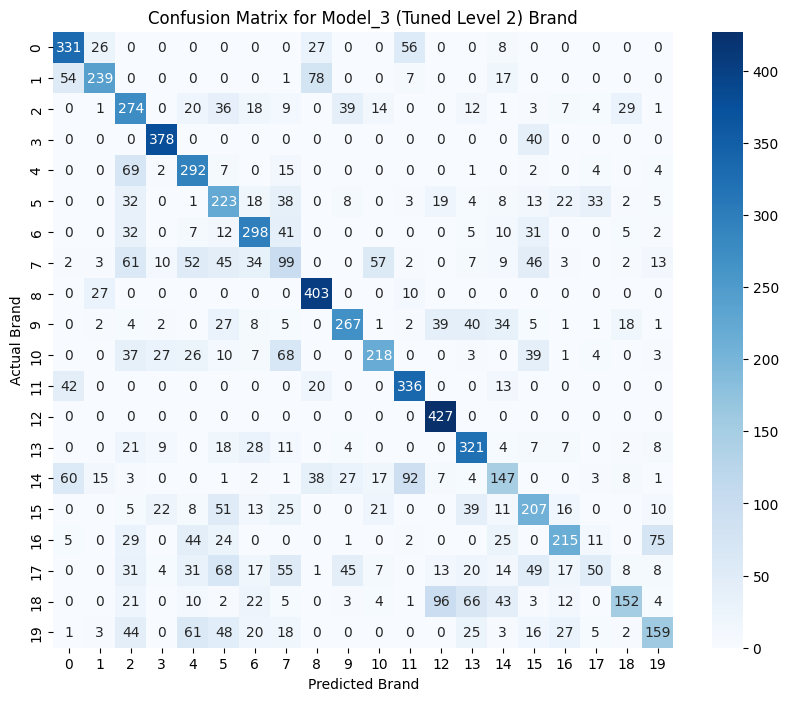

In [182]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test_price, y_pred_price_3, alpha=0.5)
plt.plot([y_test_price.min(), y_test_price.max()], [y_test_price.min(), y_test_price.max()], 'r--')
plt.title('Actual vs Predicted Prices for Model_3 (Tuned Level 2)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

print("Classification Report for Model_3 Brand:")
print(classification_report(y_test_brand, y_pred_brand_3))

cm_3 = confusion_matrix(y_test_brand, y_pred_brand_3)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Model_3 (Tuned Level 2) Brand')
plt.xlabel('Predicted Brand')
plt.ylabel('Actual Brand')
plt.show()

Perform K-Fold Cross Validation for Model_3 (Both Price and Brand)

In [183]:
cv_scores_price_3 = cross_val_score(svr_3, X_train_price, y_train_price, cv=5, scoring='r2')
cv_scores_brand_3 = cross_val_score(svm_3, X_train_brand, y_train_brand, cv=5, scoring='accuracy')

print("Model_3 Cross-Validation for Price: Mean R2 = {:.4f}, Std = {:.4f}".format(cv_scores_price_3.mean(), cv_scores_price_3.std()))
print("Model_3 Cross-Validation for Brand: Mean Accuracy = {:.4f}, Std = {:.4f}".format(cv_scores_brand_3.mean(), cv_scores_brand_3.std()))

Model_3 Cross-Validation for Price: Mean R2 = 0.8114, Std = 0.0052
Model_3 Cross-Validation for Brand: Mean Accuracy = 0.5766, Std = 0.0039


# **Model 4**

Build and Train Model_4 (Tuned Level 3 for Both Price and Brand)

In [185]:
# Fine-tune with RBF, C=100, gamma=0.1 for both
svr_4 = SVR(kernel='rbf', C=100, gamma=0.1)
svr_4.fit(X_train_price, y_train_price)
y_pred_price_4 = svr_4.predict(X_test_price)

svm_4 = SVC(kernel='rbf', C=100, gamma=0.1)
svm_4.fit(X_train_brand, y_train_brand)
y_pred_brand_4 = svm_4.predict(X_test_brand)

Calculate and Display Performance Metrics for Model_4 (Both Price and Brand)

In [186]:
mse_4 = mean_squared_error(y_test_price, y_pred_price_4)
mae_4 = mean_absolute_error(y_test_price, y_pred_price_4)
r2_4 = r2_score(y_test_price, y_pred_price_4)

accuracy_4 = accuracy_score(y_test_brand, y_pred_brand_4)
precision_4 = precision_score(y_test_brand, y_pred_brand_4, average='weighted')
recall_4 = recall_score(y_test_brand, y_pred_brand_4, average='weighted')
f1_4 = f1_score(y_test_brand, y_pred_brand_4, average='weighted')

print("Model_4 (Tuned Level 3) Metrics for Price:")
print(f"Mean Squared Error: {mse_4:.4f}")
print(f"Mean Absolute Error: {mae_4:.4f}")
print(f"R² Score: {r2_4:.4f}")

print("\nModel_4 (Tuned Level 3) Metrics for Brand:")
print(f"Accuracy: {accuracy_4:.4f}")
print(f"Precision: {precision_4:.4f}")
print(f"Recall: {recall_4:.4f}")
print(f"F1 Score: {f1_4:.4f}")

Model_4 (Tuned Level 3) Metrics for Price:
Mean Squared Error: 0.0522
Mean Absolute Error: 0.1437
R² Score: 0.9454

Model_4 (Tuned Level 3) Metrics for Brand:
Accuracy: 0.9841
Precision: 0.9841
Recall: 0.9841
F1 Score: 0.9840


Display Reports and Plots for Model_4 (Both Price and Brand)

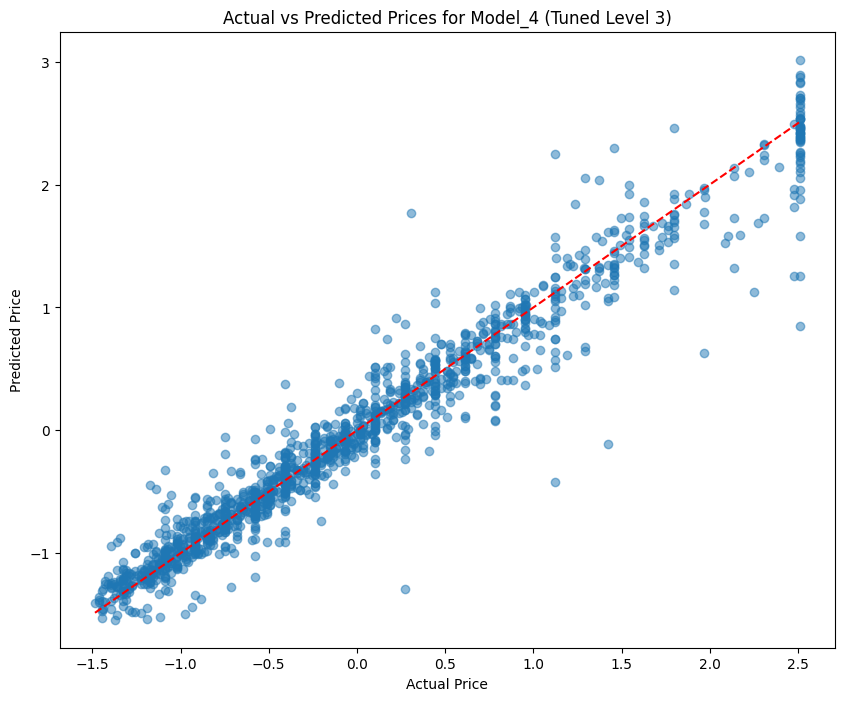

Classification Report for Model_4 Brand:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       448
           1       0.99      1.00      0.99       396
           2       0.99      0.99      0.99       468
           3       1.00      1.00      1.00       418
           4       0.99      1.00      1.00       396
           5       0.95      0.97      0.96       429
           6       0.97      0.98      0.97       443
           7       0.93      0.94      0.94       445
           8       1.00      1.00      1.00       440
           9       1.00      0.98      0.99       457
          10       0.96      0.90      0.93       443
          11       1.00      0.99      0.99       411
          12       1.00      1.00      1.00       427
          13       0.99      1.00      0.99       440
          14       1.00      1.00      1.00       426
          15       0.99      1.00      0.99       428
          16       0.98      1.00      0

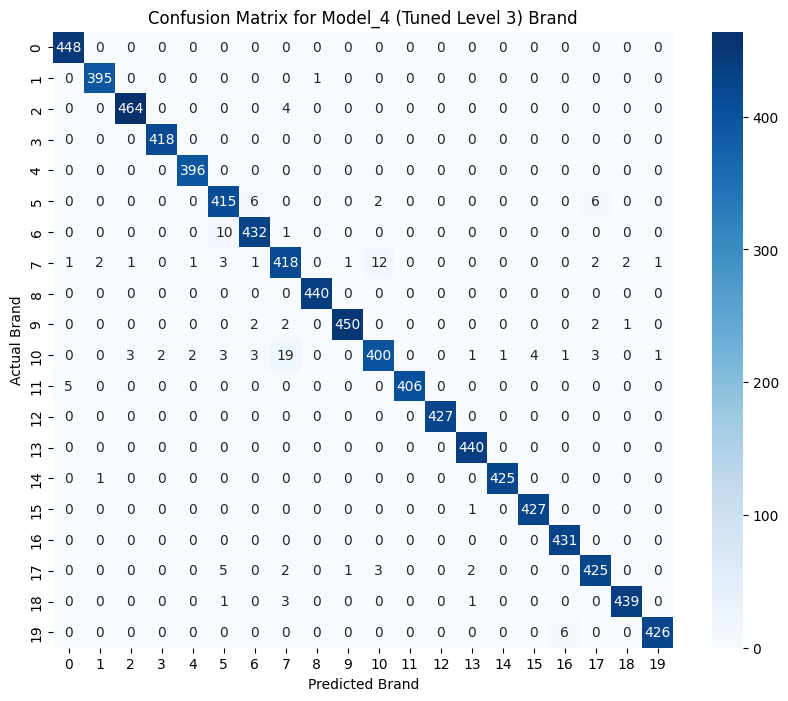

In [187]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test_price, y_pred_price_4, alpha=0.5)
plt.plot([y_test_price.min(), y_test_price.max()], [y_test_price.min(), y_test_price.max()], 'r--')
plt.title('Actual vs Predicted Prices for Model_4 (Tuned Level 3)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

print("Classification Report for Model_4 Brand:")
print(classification_report(y_test_brand, y_pred_brand_4))

cm_4 = confusion_matrix(y_test_brand, y_pred_brand_4)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_4, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Model_4 (Tuned Level 3) Brand')
plt.xlabel('Predicted Brand')
plt.ylabel('Actual Brand')
plt.show()

Perform K-Fold Cross Validation for Model_4 (Both Price and Brand)

In [189]:
cv_scores_price_4 = cross_val_score(svr_4, X_train_price, y_train_price, cv=5, scoring='r2')
cv_scores_brand_4 = cross_val_score(svm_4, X_train_brand, y_train_brand, cv=5, scoring='accuracy')

print("Model_4 Cross-Validation for Price: Mean R2 = {:.4f}, Std = {:.4f}".format(cv_scores_price_4.mean(), cv_scores_price_4.std()))
print("Model_4 Cross-Validation for Brand: Mean Accuracy = {:.4f}, Std = {:.4f}".format(cv_scores_brand_4.mean(), cv_scores_brand_4.std()))

Model_4 Cross-Validation for Price: Mean R2 = 0.9480, Std = 0.0040
Model_4 Cross-Validation for Brand: Mean Accuracy = 0.9804, Std = 0.0013


Combine All Models’ Results into Comparison Tables (Both Price and Brand)

In [190]:
# Comparison tables for price and brand
results_price = {
    'Model': ['Model_1 (Baseline)', 'Model_2 (Level 1)', 'Model_3 (Level 2)', 'Model_4 (Level 3)'],
    'MSE': [mse_1, mse_2, mse_3, mse_4],
    'MAE': [mae_1, mae_2, mae_3, mae_4],
    'R2 Score': [r2_1, r2_2, r2_3, r2_4],
    'CV Mean R2': [cv_scores_price_1.mean(), cv_scores_price_2.mean(), cv_scores_price_3.mean(), cv_scores_price_4.mean()],
    'CV Std R2': [cv_scores_price_1.std(), cv_scores_price_2.std(), cv_scores_price_3.std(), cv_scores_price_4.std()]
}
results_df_price = pd.DataFrame(results_price)
print("Comparison Table for Price:")
display(results_df_price)

results_brand = {
    'Model': ['Model_1 (Baseline)', 'Model_2 (Level 1)', 'Model_3 (Level 2)', 'Model_4 (Level 3)'],
    'Accuracy': [accuracy_1, accuracy_2, accuracy_3, accuracy_4],
    'Precision': [precision_1, precision_2, precision_3, precision_4],
    'Recall': [recall_1, recall_2, recall_3, recall_4],
    'F1 Score': [f1_1, f1_2, f1_3, f1_4],
    'CV Mean Accuracy': [cv_scores_brand_1.mean(), cv_scores_brand_2.mean(), cv_scores_brand_3.mean(), cv_scores_brand_4.mean()],
    'CV Std Accuracy': [cv_scores_brand_1.std(), cv_scores_brand_2.std(), cv_scores_brand_3.std(), cv_scores_brand_4.std()]
}
results_df_brand = pd.DataFrame(results_brand)
print("Comparison Table for Brand:")
display(results_df_brand)

Comparison Table for Price:


,Model,MSE,MAE,R2 Score,CV Mean R2,CV Std R2
0,Model_1 (Baseline),0.062043,0.172998,0.935044,0.939482,0.003992
1,Model_2 (Level 1),0.049302,0.147212,0.948384,0.952423,0.003357
2,Model_3 (Level 2),0.194134,0.339378,0.796753,0.811400,0.005159
3,Model_4 (Level 3),0.052171,0.143708,0.945381,0.947989,0.004043


Comparison Table for Brand:


,Model,Accuracy,Precision,Recall,F1 Score,CV Mean Accuracy,CV Std Accuracy
0,Model_1 (Baseline),0.899654,0.899122,0.899654,0.897761,0.885797,0.003064
1,Model_2 (Level 1),0.968707,0.968657,0.968707,0.968510,0.962240,0.003095
2,Model_3 (Level 2),0.581524,0.579270,0.581524,0.565326,0.576559,0.003867
3,Model_4 (Level 3),0.984065,0.984055,0.984065,0.983998,0.980370,0.001255


Draw Bar Charts Comparing Performance Metrics (Both Price and Brand)

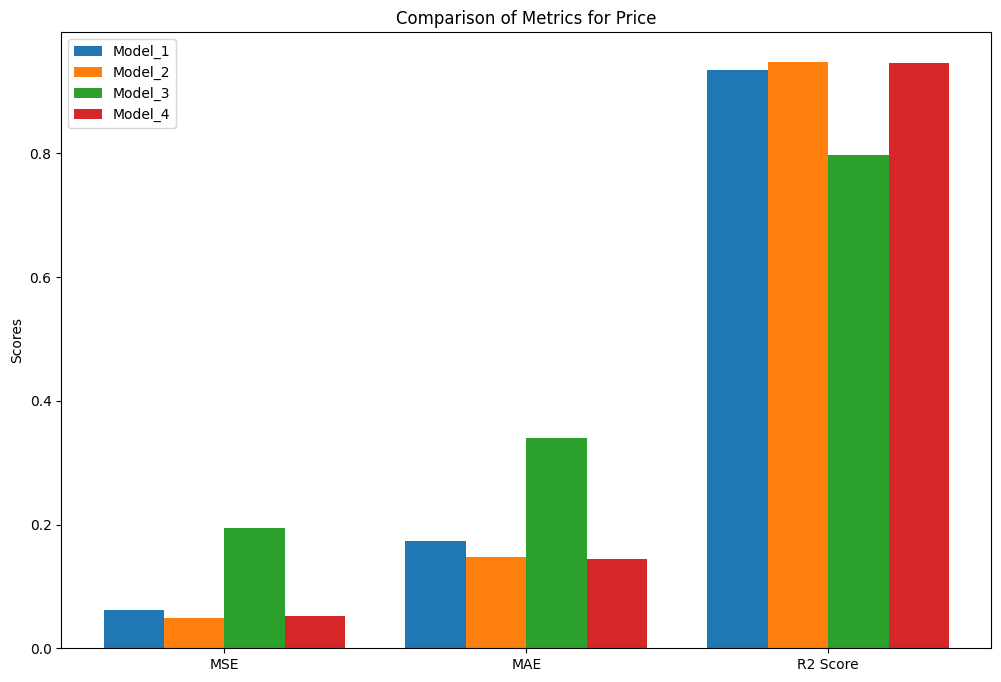

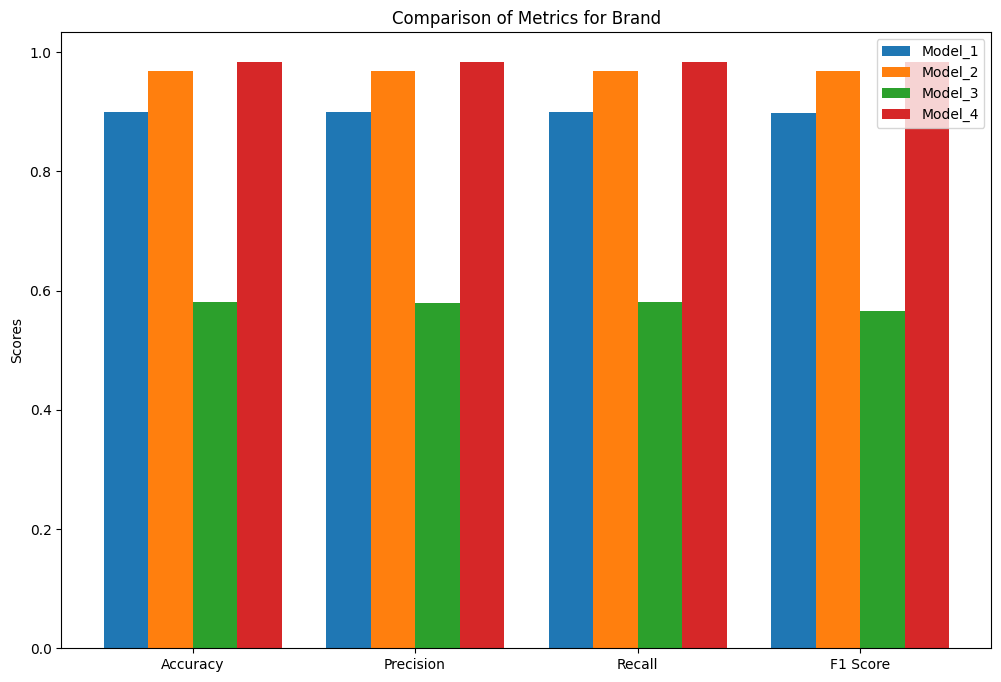

In [191]:
# Bar charts for price and brand metrics
metrics_price = ['MSE', 'MAE', 'R2 Score']
x_p = np.arange(len(metrics_price))
width = 0.2
fig_p, ax_p = plt.subplots(figsize=(12, 8))
ax_p.bar(x_p - 1.5*width, results_df_price.iloc[0, 1:4], width, label='Model_1')
ax_p.bar(x_p - 0.5*width, results_df_price.iloc[1, 1:4], width, label='Model_2')
ax_p.bar(x_p + 0.5*width, results_df_price.iloc[2, 1:4], width, label='Model_3')
ax_p.bar(x_p + 1.5*width, results_df_price.iloc[3, 1:4], width, label='Model_4')
ax_p.set_ylabel('Scores')
ax_p.set_title('Comparison of Metrics for Price')
ax_p.set_xticks(x_p)
ax_p.set_xticklabels(metrics_price)
ax_p.legend()
plt.show()

metrics_brand = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x_b = np.arange(len(metrics_brand))
fig_b, ax_b = plt.subplots(figsize=(12, 8))
ax_b.bar(x_b - 1.5*width, results_df_brand.iloc[0, 1:5], width, label='Model_1')
ax_b.bar(x_b - 0.5*width, results_df_brand.iloc[1, 1:5], width, label='Model_2')
ax_b.bar(x_b + 0.5*width, results_df_brand.iloc[2, 1:5], width, label='Model_3')
ax_b.bar(x_b + 1.5*width, results_df_brand.iloc[3, 1:5], width, label='Model_4')
ax_b.set_ylabel('Scores')
ax_b.set_title('Comparison of Metrics for Brand')
ax_b.set_xticks(x_b)
ax_b.set_xticklabels(metrics_brand)
ax_b.legend()
plt.show()

Predict Both Price and Brand Using Best Model (Model_4)

In [192]:
# Use Model_4 to predict both on test sets and display samples
predicted_prices = svr_4.predict(X_test_price)
predicted_brands = svm_4.predict(X_test_brand)

predictions_df = pd.DataFrame({
    'Actual Price': y_test_price.iloc[:10].values,
    'Predicted Price': predicted_prices[:10],
    'Actual Brand': y_test_brand.iloc[:10].values,
    'Predicted Brand': predicted_brands[:10]
})

print("Sample Predictions for Both Price and Brand (Model_4):")
display(predictions_df)

Sample Predictions for Both Price and Brand (Model_4):


,Actual Price,Predicted Price,Actual Brand,Predicted Brand
0,0.270253,-0.037512,0,0
1,2.508049,2.387507,11,11
2,1.289363,1.467007,2,2
3,-1.326353,-1.311381,12,12
4,1.204437,1.355728,6,6
5,1.119512,2.249561,14,14
6,-0.816801,-0.891500,15,15
7,-1.281682,-1.166974,8,8
8,-0.579005,-0.698046,13,13
9,0.076622,0.068541,12,12


Plot Combined Predictions (Both Price and Brand)

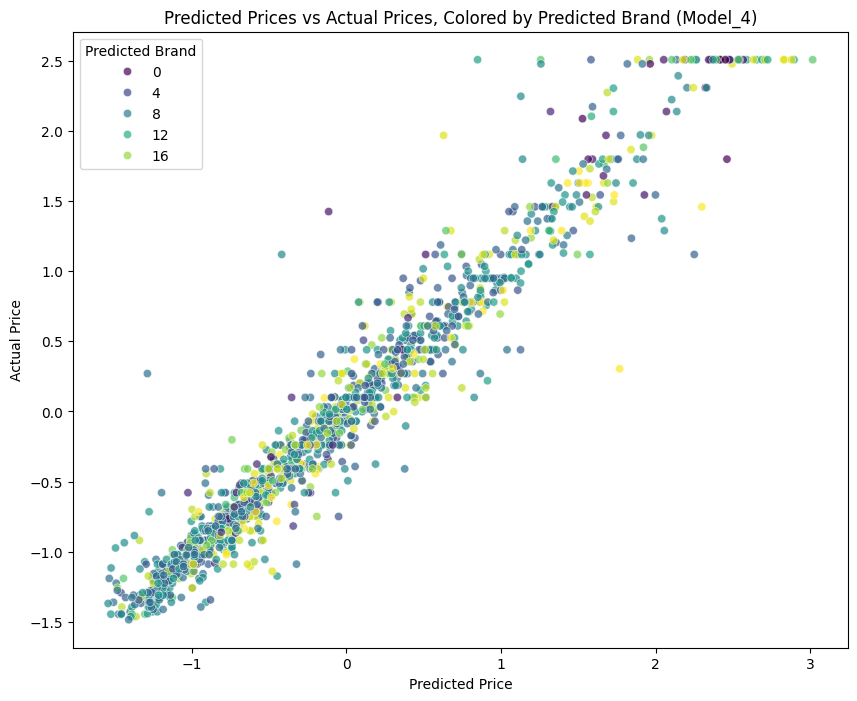

In [194]:
# Predict brands using the price test set features for consistent plotting
predicted_brands_for_price_plot = svm_4.predict(X_test_price)

# Scatter plot of predicted prices colored by predicted brands
plt.figure(figsize=(10, 8))
sns.scatterplot(x=predicted_prices, y=y_test_price.values, hue=predicted_brands_for_price_plot, palette='viridis', alpha=0.7)
plt.title('Predicted Prices vs Actual Prices, Colored by Predicted Brand (Model_4)')
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.legend(title='Predicted Brand')
plt.show()